## Data loading

In [2]:
import pandas as pd
import os


directory = "Sber-Conditional/Data/"  # set directory path
d = {}
formed = {}

for i, entry in enumerate(os.scandir(directory)):  
    if entry.is_file() and entry.name.endswith('.xlsx'):  # check if it's a file
        # print(entry.name)
        d[entry.name] = pd.read_excel(f"{directory}{entry.name}")
    elif entry.is_file() and entry.name.endswith('.csv'):
        formed[entry.name] = pd.read_csv(f"{directory}{entry.name}")
        

---
## Data prepocessing

In [3]:
global_macros = d["global_macro.xlsx"]
apk_nona = formed["apk_nona.csv"]

In [4]:
global_macros = global_macros.drop(columns=["Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),  .1"])

In [5]:
apk_nona["Date"] = apk_nona["Unnamed: 0"]
apk_nona["Date"] = pd.to_datetime(apk_nona["Date"])

In [6]:
global_macros = global_macros.iloc[3:][::-1].reset_index(drop=True)
global_macros = global_macros.drop(columns=["Date"])
global_macros.index = apk_nona["Date"]

apk_nona = apk_nona.set_index('Date')

In [7]:
assert global_macros.shape[0] == apk_nona.shape[0]

In [8]:
from utils.data_prepocessing import _ensure_monthly_index_and_align_exog, plot_forecaster_feature_importance

apk_nona_en, global_macros_en = _ensure_monthly_index_and_align_exog(apk_nona, global_macros)

---
## Time series aggregation per cluster

In [115]:
from utils.constants import CATEGORY_MAP
import matplotlib.pyplot as plt 


def normalize_series(s: pd.Series, method: str = "index"):
    """
    Normalize a Series. method in {"index", "minmax", "zscore"}.
    - "index": value / first_non_null_value * 100
    - "minmax": (value - min) / (max - min)
    - "zscore": (value - mean) / std
    """
    s = s.copy()
    if method == "index":
        # use first non-null value as base
        first = s.dropna().iloc[0] if not s.dropna().empty else None
        if first is None or first == 0:
            return s * float("nan")
        return s / first * 100.0
    elif method == "minmax":
        lo = s.min()
        hi = s.max()
        if hi == lo:
            return (s - lo)  # all zeros
        return (s - lo) / (hi - lo)
    elif method == "zscore":
        mu = s.mean()
        sigma = s.std()
        if sigma == 0:
            return s - mu
        return (s - mu) / sigma
    else:
        raise ValueError("Unknown normalization method")


def plot_trend_for_cat(df: pd.DataFrame,
                       rolling_window_months: int = 12,
                       require_full_window: bool = True,
                       norm_method: str = 'index') -> None:
    fig, ax = plt.subplots(4, 2, figsize=(19,15))
    cols_to_plot = []
    df.columns = [col.replace("/", " ") for col in df.columns]
    # --- Create category sums ---
    for idx, category in enumerate(set(CATEGORY_MAP.values())):
        # Get all columns belonging to this category that are present in df
        cols = [col for col, cat in CATEGORY_MAP.items() if cat == category and col in df.columns]
    
        if cols:  # only if such columns exist in df
            df[f"{category}_sum"] = df[cols].sum(axis=1)
            # compute rolling sum over specified months
            minp = rolling_window_months if require_full_window else 1
            rolling_col_name = f"{category}_{rolling_window_months}m_sum"
            df[rolling_col_name] = df[f"{category}_sum"].rolling(window=rolling_window_months,
                                                             min_periods=minp).sum()
            norm_monthly = normalize_series(df[f"{category}_sum"], method=norm_method)
            norm_rolling = normalize_series(df[rolling_col_name], method=norm_method)
            df[f"{category}_sum"] = norm_monthly
            df[rolling_col_name] = norm_rolling
            idx_plot_y = idx % 4
            idx_plot_x = int(idx >= 4)
            
            fig.patch.set_facecolor('lightgray')
            ax[idx_plot_y, idx_plot_x].grid(axis='x', linestyle=':', alpha=0.6)
            ax[idx_plot_y, idx_plot_x].set_title(f'{category} index stats')
            ax[idx_plot_y, idx_plot_x].set_facecolor('lightgray')
            ax[idx_plot_y, idx_plot_x].plot(df.index, norm_monthly, linewidth=2, color="maroon", label=f'{category} sum')
            ax[idx_plot_y, idx_plot_x].plot(df.index, norm_rolling, linewidth=2, color="steelblue", label=f'roling windw {rolling_window_months} month sum')
            ax[idx_plot_y, idx_plot_x].legend()
    plt.show()
    return df

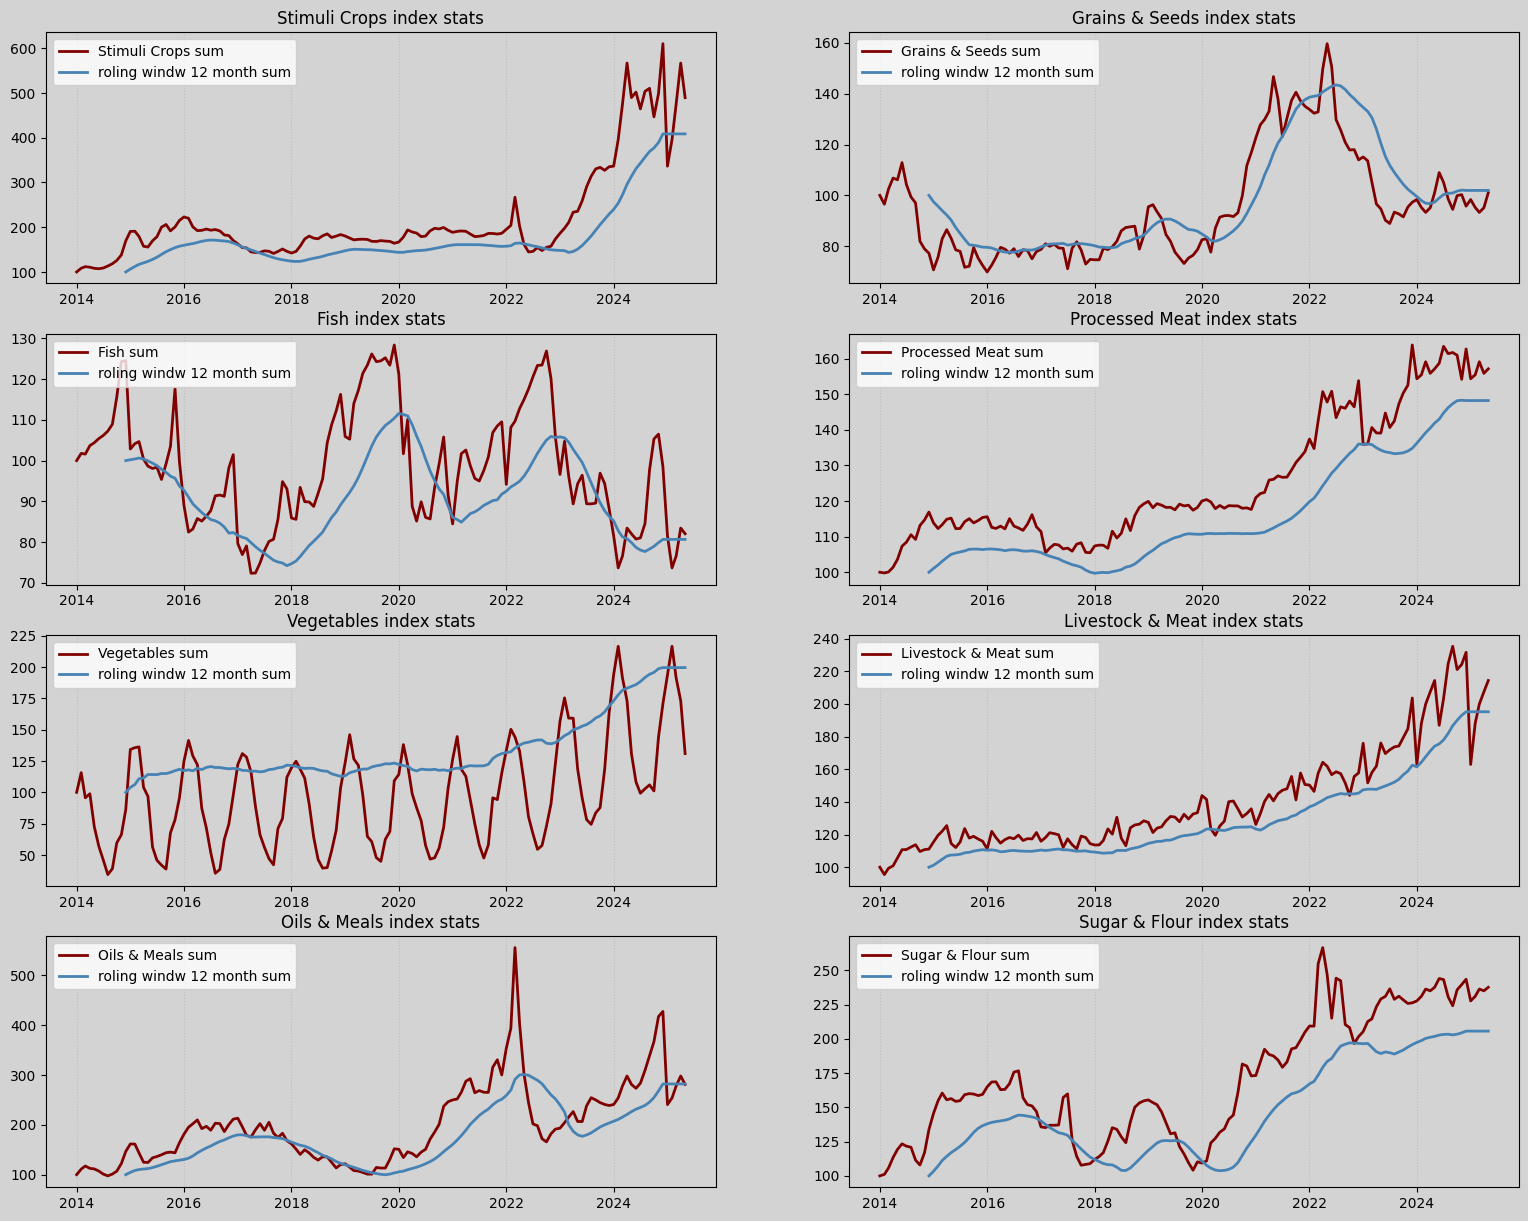

In [33]:
plot_trend_for_cat(apk_nona_en, 12, norm_method="index")

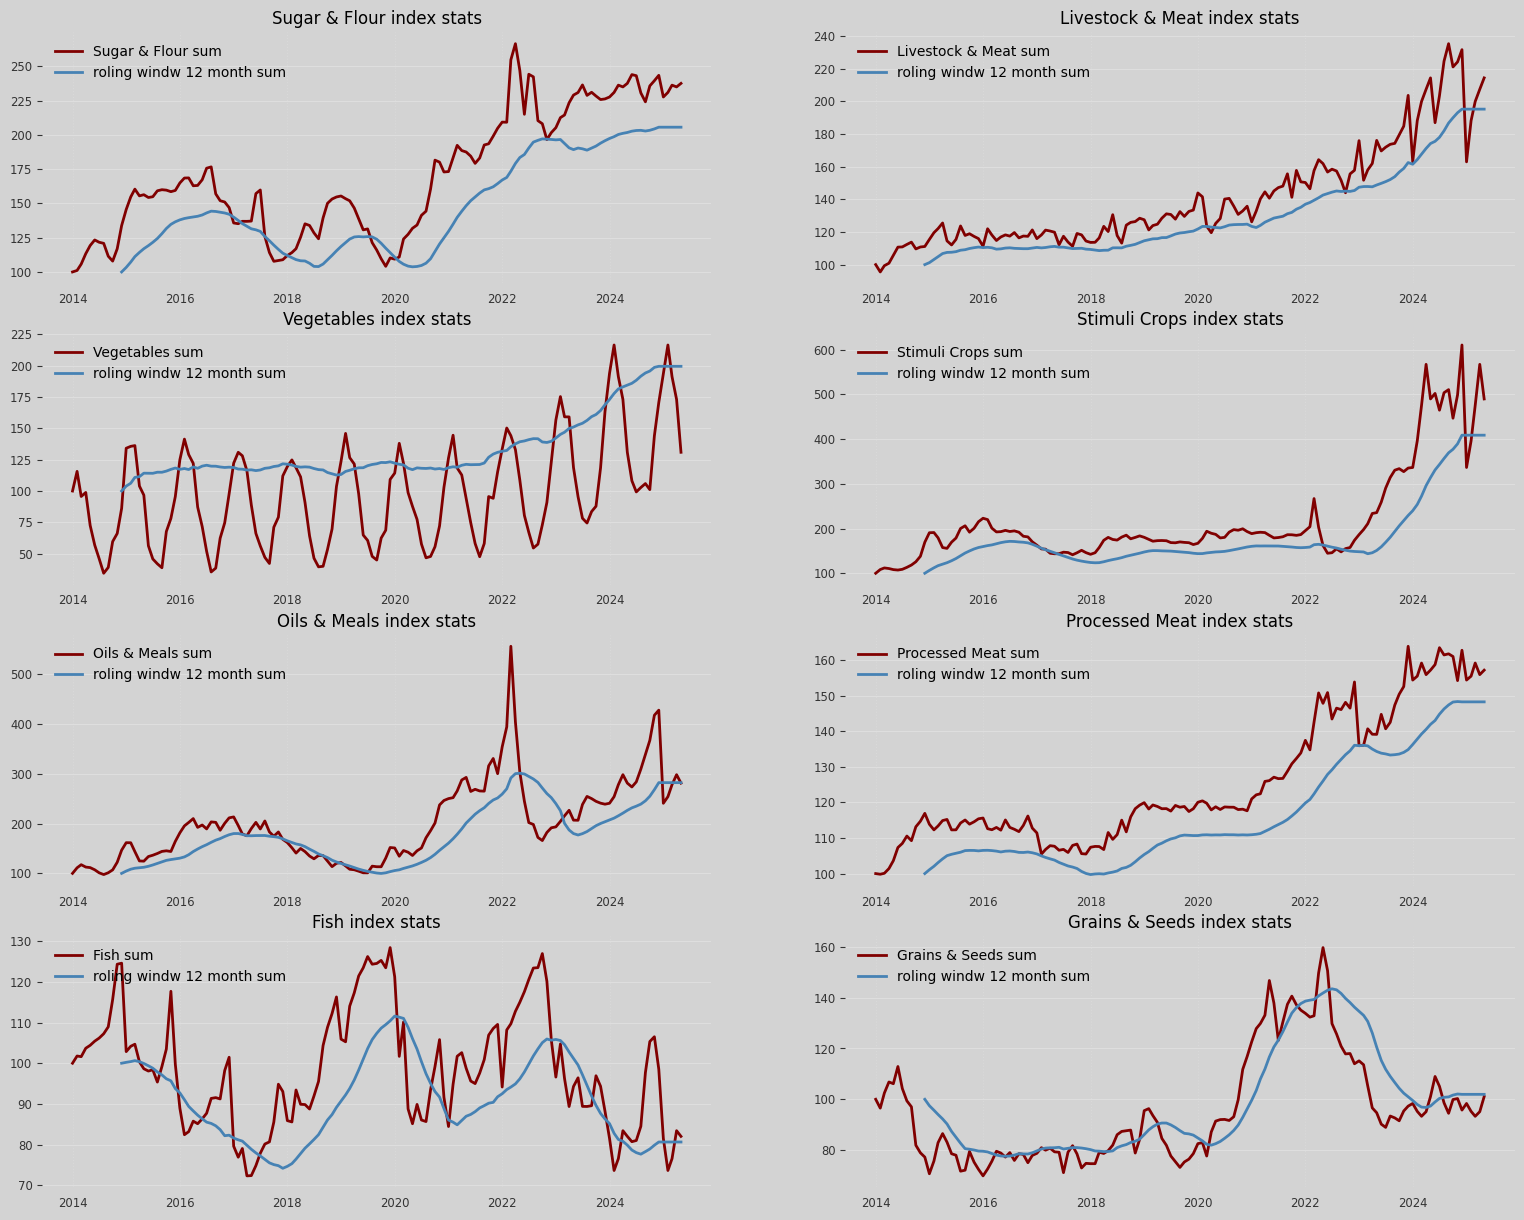

In [116]:
apk_nona_en_rol = plot_trend_for_cat(apk_nona_en, 12, norm_method="index")

In [117]:
apk_nona_en_rol

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,Fish_sum,Fish_12m_sum,Livestock & Meat_sum,Livestock & Meat_12m_sum,Stimuli Crops_sum,Stimuli Crops_12m_sum,Processed Meat_sum,Processed Meat_12m_sum,Grains & Seeds_sum,Grains & Seeds_12m_sum
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,100.000000,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,101.773755,NaN,95.503399,NaN,108.310824,NaN,99.812954,NaN,96.509627,NaN
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,101.611553,NaN,99.343364,NaN,111.882290,NaN,100.086470,NaN,102.468076,NaN
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,103.681457,NaN,100.847265,NaN,110.546772,NaN,101.404963,NaN,106.810051,NaN
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,104.400377,NaN,105.713799,NaN,108.133217,NaN,103.622187,NaN,106.131052,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,81.529929,80.650984,162.938757,195.215766,336.417699,408.576686,154.342682,148.220945,98.349660,101.943349
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,73.650063,80.650984,188.187189,195.215766,395.941919,408.576686,155.445907,148.220945,95.236933,101.943349
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,76.553997,80.650984,199.897243,195.215766,475.169934,408.576686,159.122775,148.220945,93.305496,101.943349


In [142]:
def plot_preds_on_curve(preds: pd.DataFrame,
                        label: pd.DataFrame,
                        mape_val: str,
                        predictor_name: str|list[str],
                        cat_name: str,
                        save_dir: str):
    pred_names = "|".join(predictor_name) if isinstance(predictor_name, list) else predictor_name
        
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('lightgray')
    ax.plot(preds.index, preds, color="maroon", label=f"Sum index of {cat_name} preds")
    ax.plot(label.index, label, color="steelblue", label=f"Sum index of {cat_name} label")
    ax.legend()
    ax.set_title(f"Sum index {cat_name} preds vs labels with predictor {pred_names}; curr mape: {mape_val:.2f}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sum")
    ax.set_facecolor('lightgray')
    plt.savefig(f'{save_dir}/{cat_name}_by_{pred_names}_sum_index_one_year.png')

In [143]:
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, mae, rmse
import pandas as pd
from typing import Dict, Optional


class ClusterForecaster:
    def __init__(self,
                 cluster_data: pd.DataFrame,
                 macro_data: pd.DataFrame,
                 category_map: Dict[str, str],
                 freq: str = "M",
                 target_col_suffix: str = "_sum",
                 dir_to_save_plots: str = "darts_result",
                 dir_to_save_tables: str = "darts_result_tables"):
        self.cluster_data = cluster_data
        self.macro_data = macro_data
        self.category_map = category_map
        self.freq = freq
        self.scaler_target = Scaler()
        self.scaler_cov = Scaler()
        self.model = None
        self.target_col_suffix = target_col_suffix
        self.dir_to_save_plots = dir_to_save_plots
        self.dir_to_save_tables = dir_to_save_tables

    def _aggregate_clusters(self) -> pd.DataFrame:
        df = pd.DataFrame(index=self.cluster_data.index)
        for cluster in set(self.category_map.values()):
            cols = [c for c, cat in self.category_map.items()
                    if cat == cluster and c in self.cluster_data.columns]
            if cols:
                df[cluster] = self.cluster_data[cols].sum(axis=1)
        return df

    def _prepare_series(self,
                        target_col: str,
                        train_end: pd.Timestamp = None,
                        covariates: Optional[pd.DataFrame] = None):
        # slice up to train_end
        if train_end is not None:
            mask = self.cluster_data.index <= train_end
            target_slice = self.cluster_data.loc[mask, f"{target_col}{self.target_col_suffix}"]
            cov_slice = covariates.loc[mask, :]
        else:
            target_slice = self.cluster_data[f"{target_col}{self.target_col_suffix}"]
            cov_slice = covariates

        target_ts = TimeSeries.from_series(target_slice, freq='M')
        cov_ts = None
        if covariates is not None:
            cov_ts = TimeSeries.from_dataframe(covariates, freq='M')
        return target_ts, cov_ts

    def train(self,
              target_cluster: str,
              additional_cluster: Optional[str] = None,
              use_macro: bool = True,
              past_covariate_lags: int = 12,
              train_end: pd.Timestamp = None,
              model_type: str = "NBEATS",
              **model_kwargs):
        """
        Train model up to train_end (inclusive).
        If train_end is None, use full series except last output chunk.
        """
        # build covariates DataFrame
        cov_df = pd.DataFrame(index=self.cluster_data.index)
        if use_macro:
            cov_df = pd.concat([cov_df, self.macro_data], axis=1)
        if additional_cluster:
            # include lagged additional cluster series
            cov_df[f"{additional_cluster}_lag1"] = self.cluster_data[f"{additional_cluster}{self.target_col_suffix}"].shift(1)

        # fill missing values (bfill or ffill as needed)
        cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")

        # convert to Darts time series
        target_ts, cov_ts = self._prepare_series(target_cluster, train_end, cov_df)

        # scaling
        # target_ts_scaled = self.scaler_target.fit_transform(target_ts)
        # cov_ts_scaled = None
        # if cov_ts is not None:
        #     cov_ts_scaled = self.scaler_cov.fit_transform(cov_ts[f"{target_cluster}_sum"])
        #     print(cov_ts_scaled)

        # choose model
        if model_type == "NBEATS":
            model = NBEATSModel(input_chunk_length=past_covariate_lags,
                                output_chunk_length=12,
                                **model_kwargs)
        else:
            raise NotImplementedError(f"Model type {model_type} not implemented")

        # fit model
        model.fit(series=target_ts, past_covariates=cov_ts, verbose=True)

        self.model = model
        # store the slices used for training
        self._train_target_ts = target_ts
        self._train_cov_ts = cov_ts
        self._train_end = train_end

    def forecast(self, n: int = 12, covariates_future: Optional[pd.DataFrame] = None):
        """
        Forecast the next n steps beyond training data.
        If covariates_future is provided, it should cover the future period.
        """
        if self.model is None:
            raise RuntimeError("Model not trained yet")

        if covariates_future is not None:
            cov_future_ts = TimeSeries.from_dataframe(covariates_future, freq="M")
            # cov_future_ts = self.scaler_cov.transform(cov_future_ts)
        else:
            cov_future_ts = None

        pred = self.model.predict(n=n, past_covariates=cov_future_ts)
        # pred = self.scaler_target.inverse_transform(pred_scaled)
        return pred

    def backtest(self,
                 target_cluster: str,
                 additional_cluster: Optional[str] = None,
                 use_macro: bool = True,
                 past_covariate_lags: int = 12,
                 start_backtest: pd.Timestamp = None,
                 forecast_horizon: int = 12,
                 model_type: str = "NBEATS",
                 **model_kwargs):
        """
        Do a one-step backtest: train on everything before `start_backtest`, forecast forecast_horizon steps,
        and compare with actuals.
        Returns (predicted_series, actual_series, dict of metrics).
        """
        if start_backtest is None:
            raise ValueError("Please supply a start backtest date")

        # train up to just before backtest
        train_end = start_backtest - pd.offsets.MonthBegin(1)
        self.train(target_cluster=target_cluster,
                   additional_cluster=additional_cluster,
                   use_macro=use_macro,
                   past_covariate_lags=past_covariate_lags,
                   train_end=train_end,
                   model_type=model_type,
                   **model_kwargs)

        # Prepare the covariates for the forecast period
        # covariates_future should be aligned to the next n periods after train_end
        future_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                                   periods=forecast_horizon,
                                   freq="MS")
        cov_future = pd.DataFrame(index=future_idx)
        if use_macro:
            cov_future = pd.concat([cov_future, self.macro_data], axis=1)
        if additional_cluster:
            # use lagged additional cluster’s known values
            # shift by one period so that at time t we use additional_cluster at t-1
            all_add = self.cluster_data[f"{additional_cluster}{self.target_col_suffix}"].shift(1)
            cov_future[f"{additional_cluster}_lag1"] = all_add.reindex(future_idx)
        cov_future = cov_future.fillna(method="bfill").fillna(method="ffill")

        # forecast
        pred_ts = self.forecast(n=forecast_horizon, covariates_future=cov_future)

        # actual in that period
        actual = self.cluster_data[f"{target_cluster}{self.target_col_suffix}"].reindex(future_idx)
        actual_ts = TimeSeries.from_series(actual)

        # metrics
        mape_val = mape(actual_ts, pred_ts)
        mae_val = mae(actual_ts, pred_ts)
        rmse_val = rmse(actual_ts, pred_ts)
        plot_preds_on_curve(pred_ts.to_dataframe(),
                            actual_ts.to_dataframe(),
                            mape_val,
                            additional_cluster,
                            target_cluster,
                            self.dir_to_save_tables)
        metrics = {"MAPE": mape_val, "MAE": mae_val, "RMSE": rmse_val}
        pred_ts.to_dataframe().to_csv(f"{self.dir_to_save_tables}/{target_cluster}_by_{additional_cluster}_preds.csv", index=False)

        return pred_ts, actual_ts, metrics


C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\3941848649.py:89: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.9 M  | train
-------------------------------------------------------------
6.9 M     Trainable params
1.9 K     Non-trainable params
6.9 M     Total params
27.498    Total estimat

Training: |                                                                                      | 0/? [00:00<…


Detected KeyboardInterrupt, attempting graceful shutdown ...

KeyboardInterrupt



In [123]:
apk_nona_en_rol

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,Fish_sum,Fish_12m_sum,Livestock & Meat_sum,Livestock & Meat_12m_sum,Stimuli Crops_sum,Stimuli Crops_12m_sum,Processed Meat_sum,Processed Meat_12m_sum,Grains & Seeds_sum,Grains & Seeds_12m_sum
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,100.000000,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN,100.000000,NaN
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,101.773755,NaN,95.503399,NaN,108.310824,NaN,99.812954,NaN,96.509627,NaN
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,101.611553,NaN,99.343364,NaN,111.882290,NaN,100.086470,NaN,102.468076,NaN
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,103.681457,NaN,100.847265,NaN,110.546772,NaN,101.404963,NaN,106.810051,NaN
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,104.400377,NaN,105.713799,NaN,108.133217,NaN,103.622187,NaN,106.131052,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,81.529929,80.650984,162.938757,195.215766,336.417699,408.576686,154.342682,148.220945,98.349660,101.943349
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,73.650063,80.650984,188.187189,195.215766,395.941919,408.576686,155.445907,148.220945,95.236933,101.943349
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,76.553997,80.650984,199.897243,195.215766,475.169934,408.576686,159.122775,148.220945,93.305496,101.943349


In [135]:
apk_nona_en_rol.dropna()

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,Fish_sum,Fish_12m_sum,Livestock & Meat_sum,Livestock & Meat_12m_sum,Stimuli Crops_sum,Stimuli Crops_12m_sum,Processed Meat_sum,Processed Meat_12m_sum,Grains & Seeds_sum,Grains & Seeds_12m_sum
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,2014-12-01,56.5599,6.48444,20.79174,69.66108,81.60369,15.374010,5.288410,8.022490,6.937420,...,124.570950,100.000000,111.102715,100.000000,169.378278,100.000000,116.913064,100.000000,77.243746,100.000000
2015-01-01,2015-01-01,64.3254,7.54969,21.12141,69.35314,84.69783,15.785100,8.253940,8.788720,7.076000,...,102.846379,100.218316,115.406595,101.203113,190.558043,106.379732,113.856829,101.078147,70.688432,97.480827
2015-02-01,2015-02-01,64.1550,8.14100,21.57078,71.79419,88.25380,19.391290,7.931550,10.171690,7.889920,...,104.164923,100.401718,119.554031,103.081246,190.990167,112.204417,112.276464,102.047885,75.703206,95.692626
2015-03-01,2015-03-01,60.1296,8.57729,21.71585,72.23692,92.37027,20.376420,9.395350,9.666220,8.026900,...,104.667225,100.636087,122.058537,104.855091,179.272786,116.952016,113.366362,103.081143,82.912054,94.011890
2015-04-01,2015-04-01,52.8285,8.29206,21.37501,71.11590,94.32434,20.033610,9.706390,9.393860,7.978870,...,100.334868,100.379405,125.490834,106.779527,157.440914,120.255666,114.889029,104.130287,86.493406,92.265783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,81.529929,80.650984,162.938757,195.215766,336.417699,408.576686,154.342682,148.220945,98.349660,101.943349
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,73.650063,80.650984,188.187189,195.215766,395.941919,408.576686,155.445907,148.220945,95.236933,101.943349
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,76.553997,80.650984,199.897243,195.215766,475.169934,408.576686,159.122775,148.220945,93.305496,101.943349


C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\2546582183.py:78: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.7 M  | train
-------------------------------------------------------------
6.7 M     Trainable params
1.8 K     Non-trainable params
6.7 M     Total params
26.726    Total estimat

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=200` reached.
C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\2546582183.py:165: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_future = cov_future.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\omirz\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\2546582183.py:78: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.7 M  | train
-------------------------------------------------------------
6.7 M     Trainable params
1.8 K     Non-trainable params
6.7 M     Total params
26.726    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode
C:\Users\omirz\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.war

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=200` reached.
C:\Users\omirz\AppData\Local\Temp\ipykernel_42532\2546582183.py:165: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_future = cov_future.fillna(method="bfill").fillna(method="ffill")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\omirz\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |                                                                                    | 0/? [00:00<…

Metrics: {'MAPE': 9.78242994585975, 'MAE': 14.409763779483093, 'RMSE': 14.98144379725852}


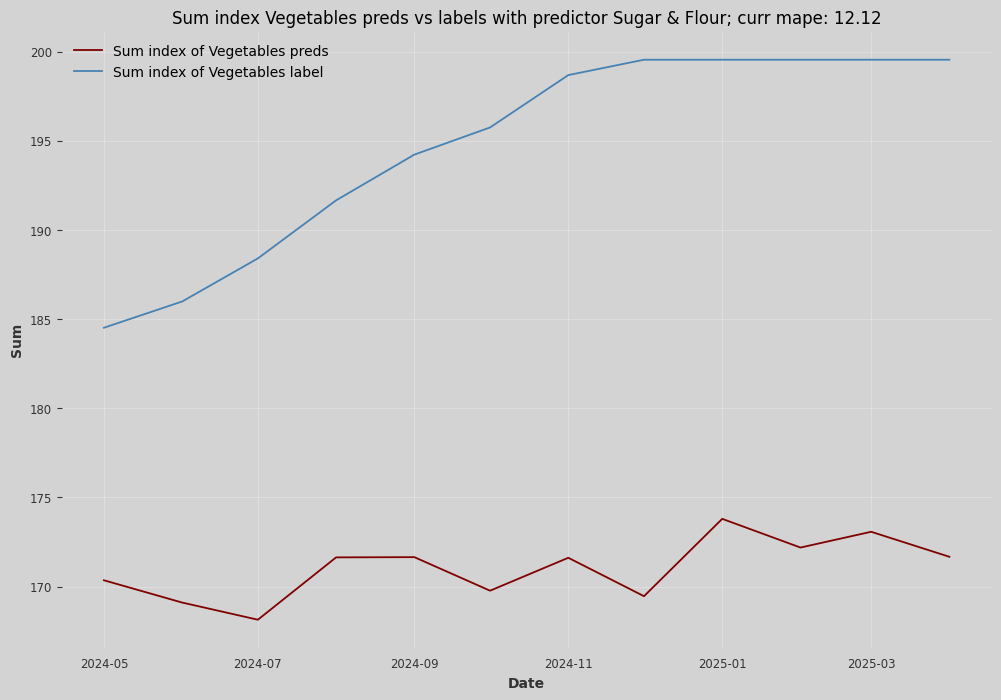

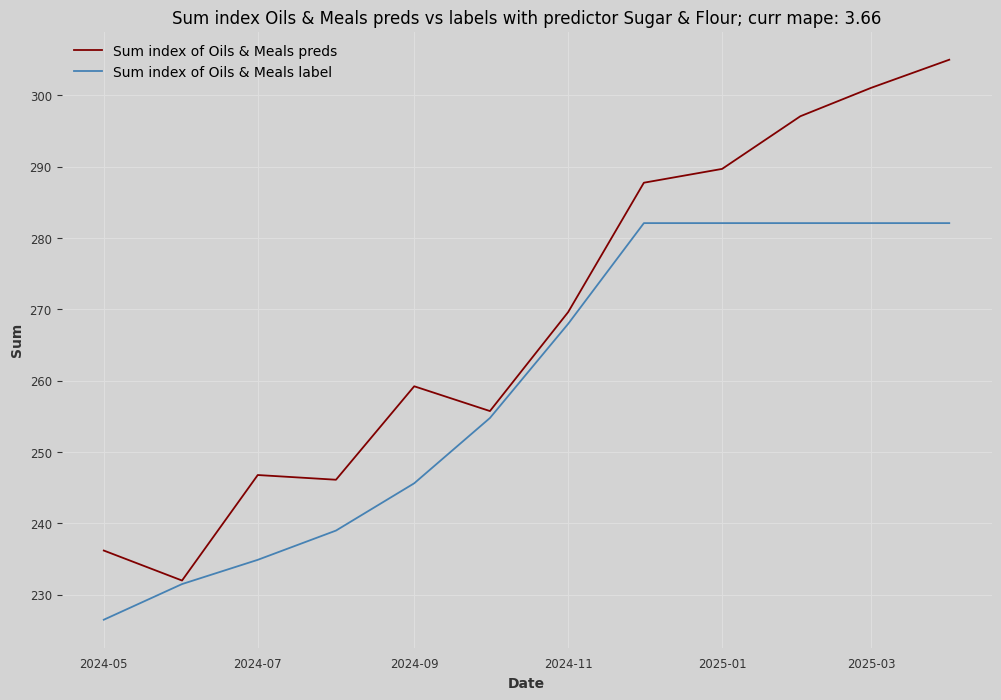

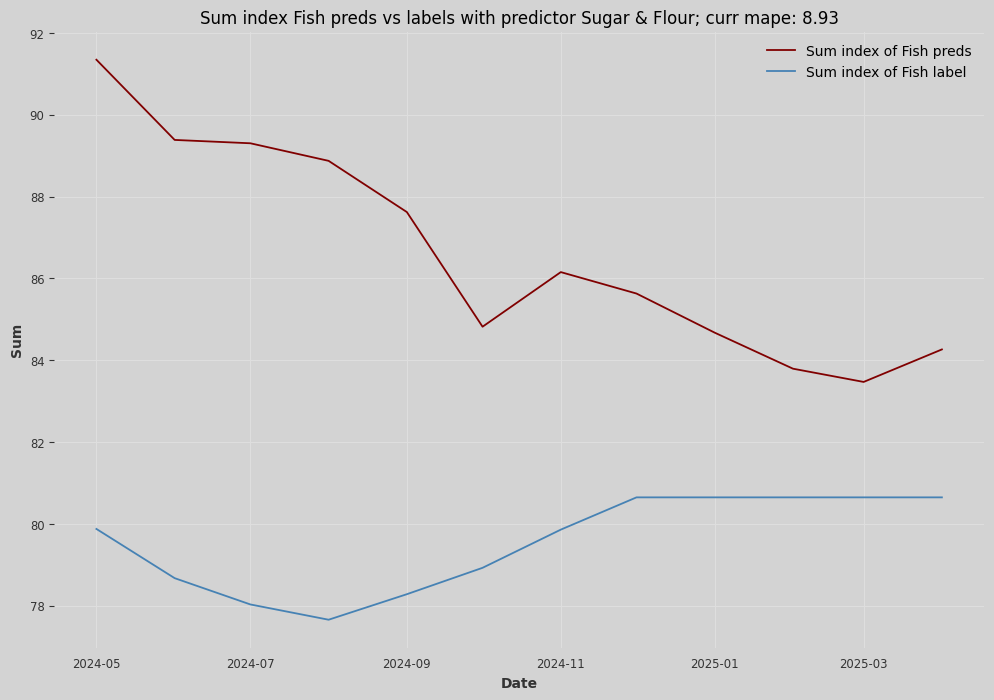

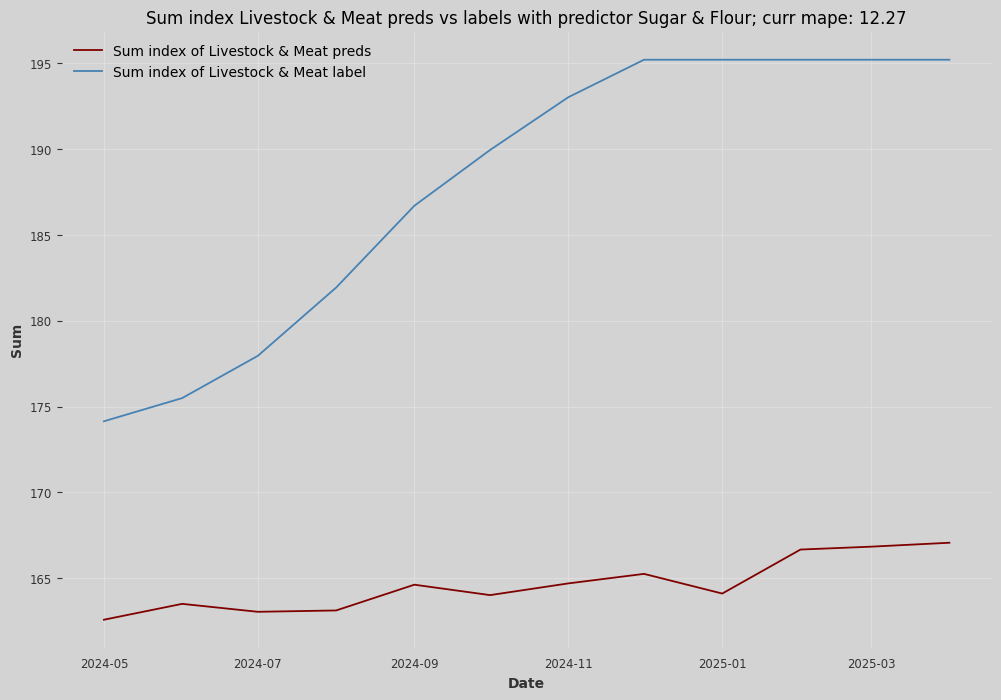

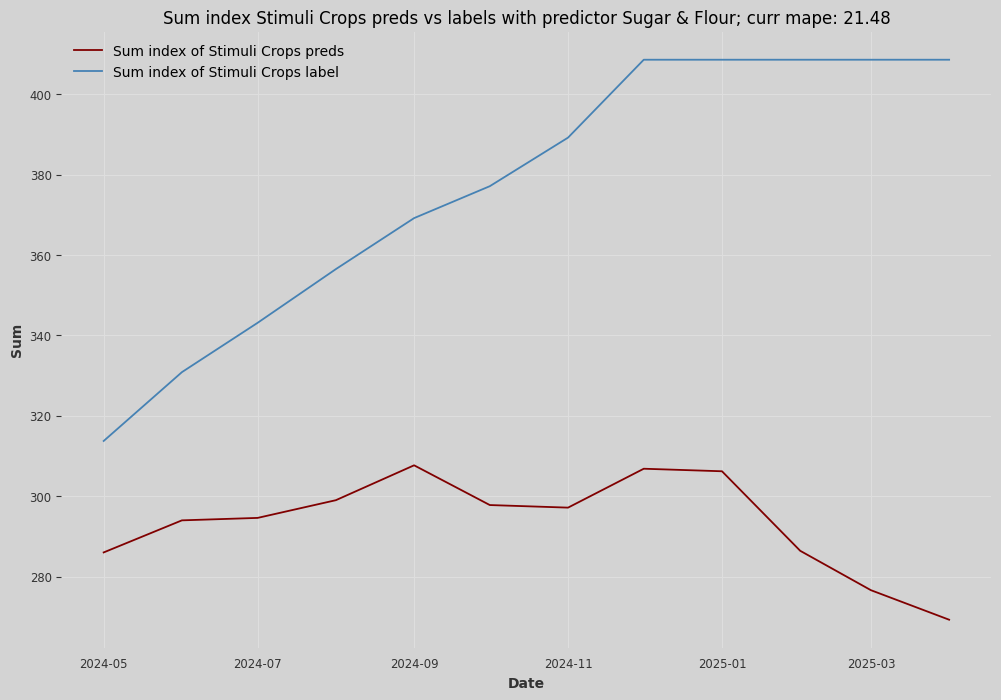

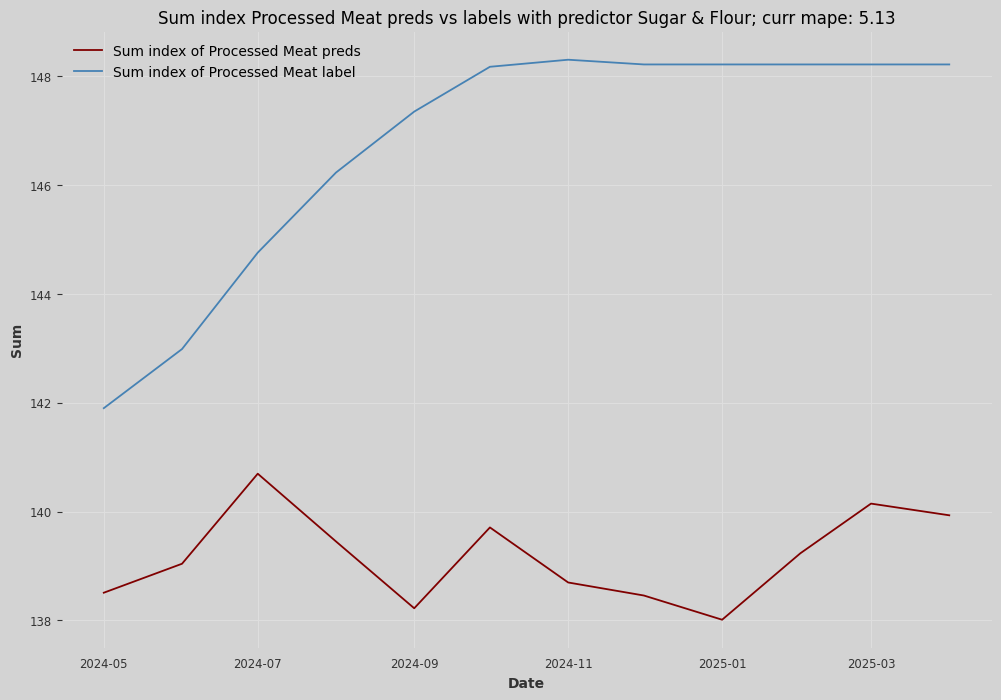

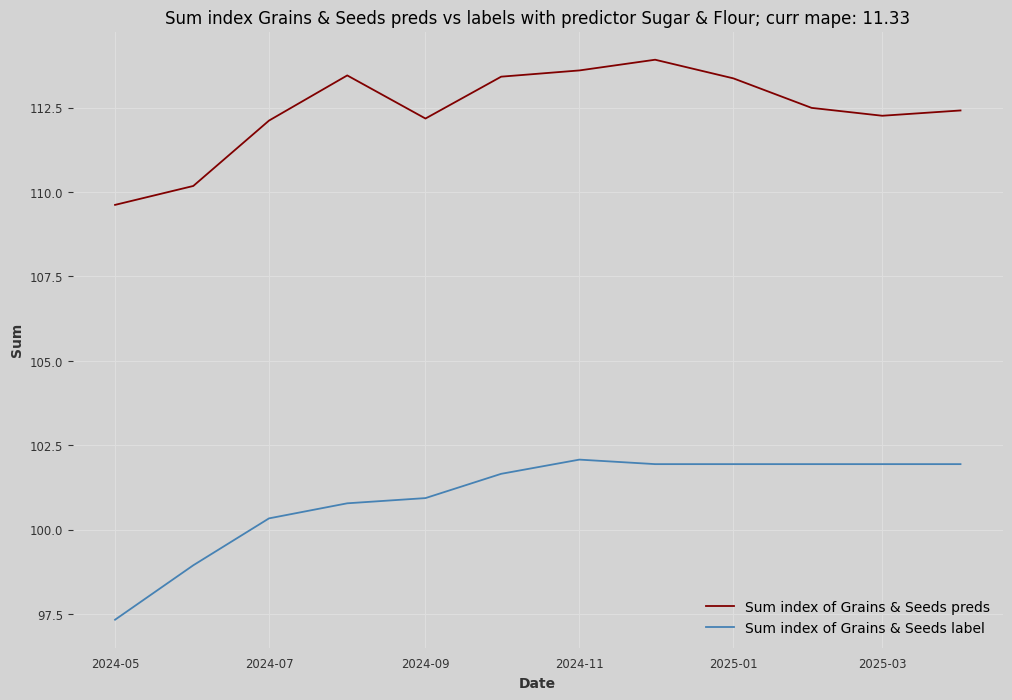

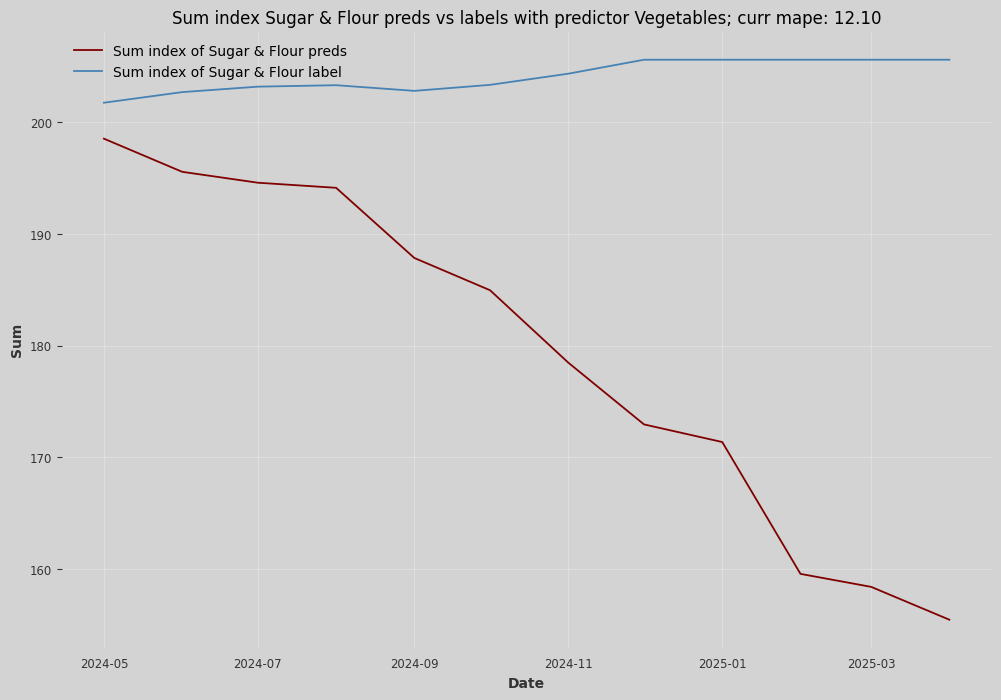

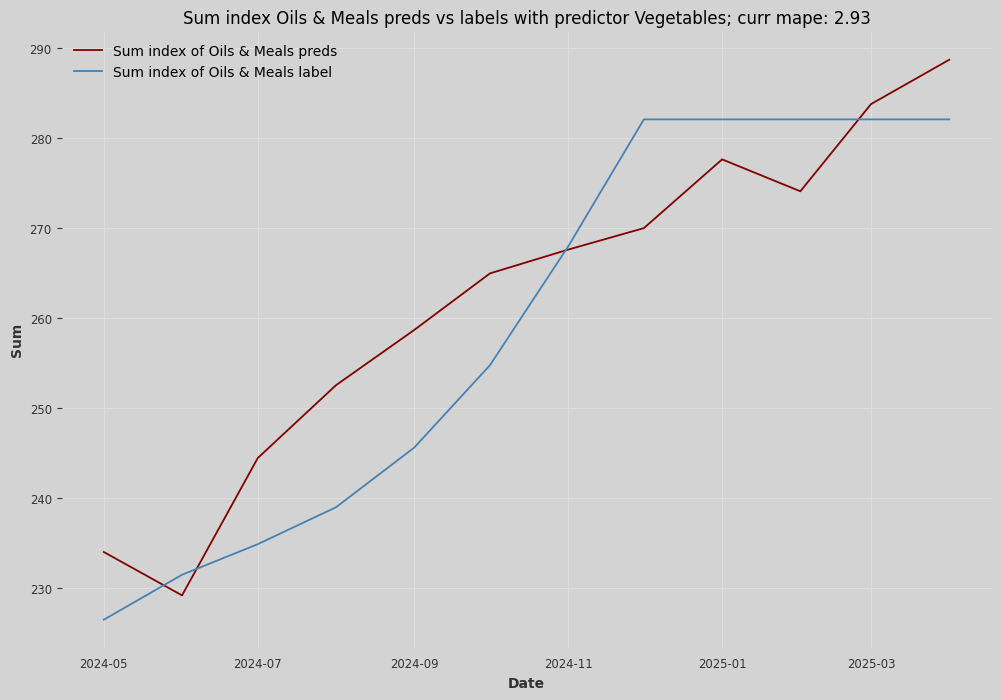

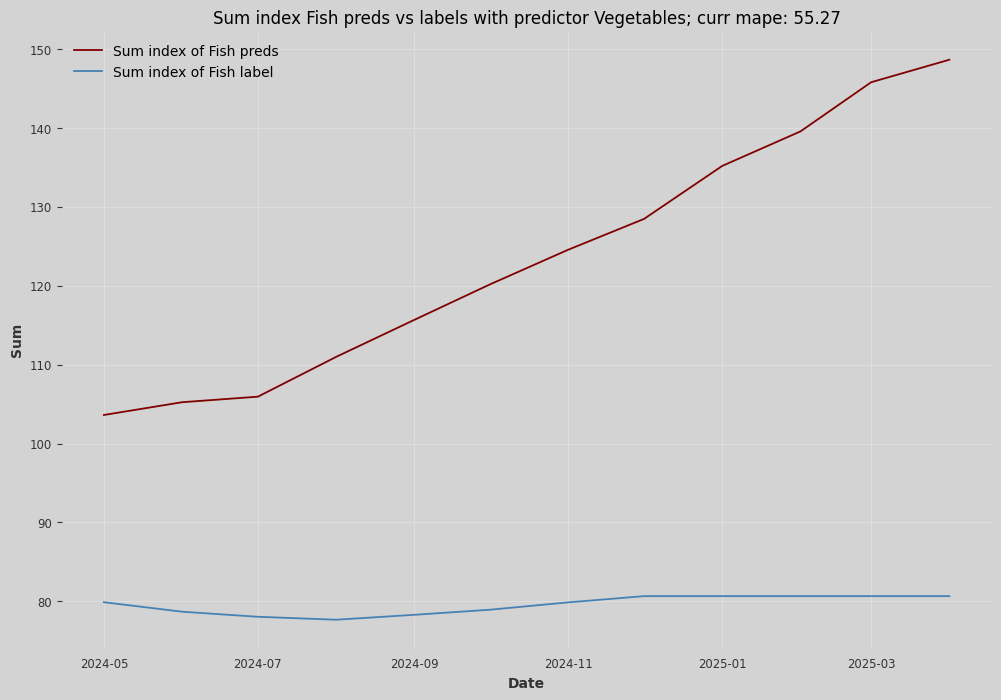

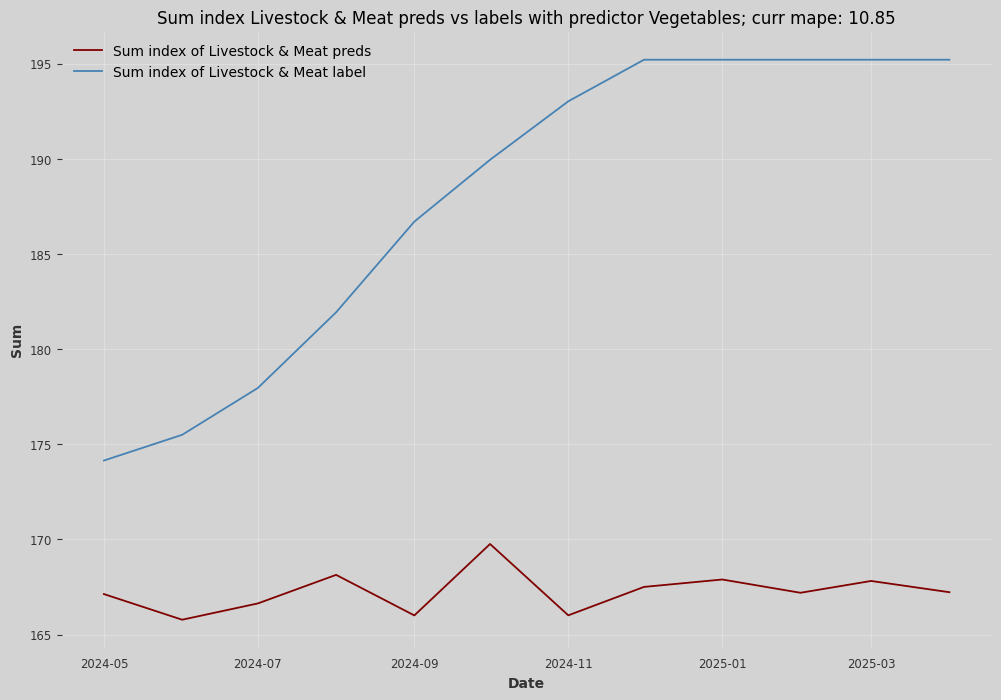

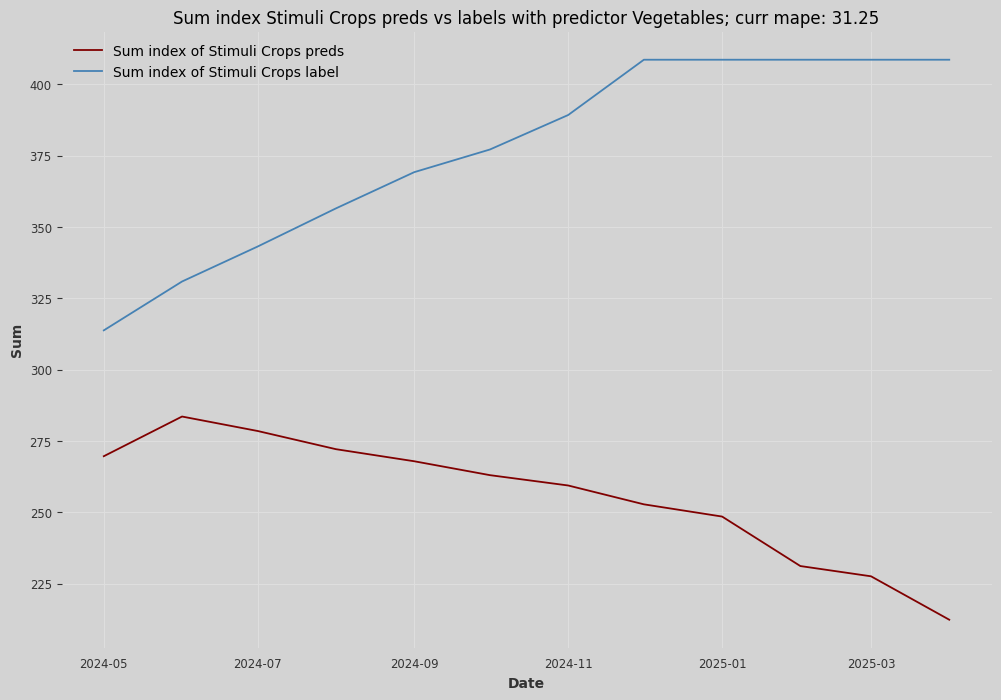

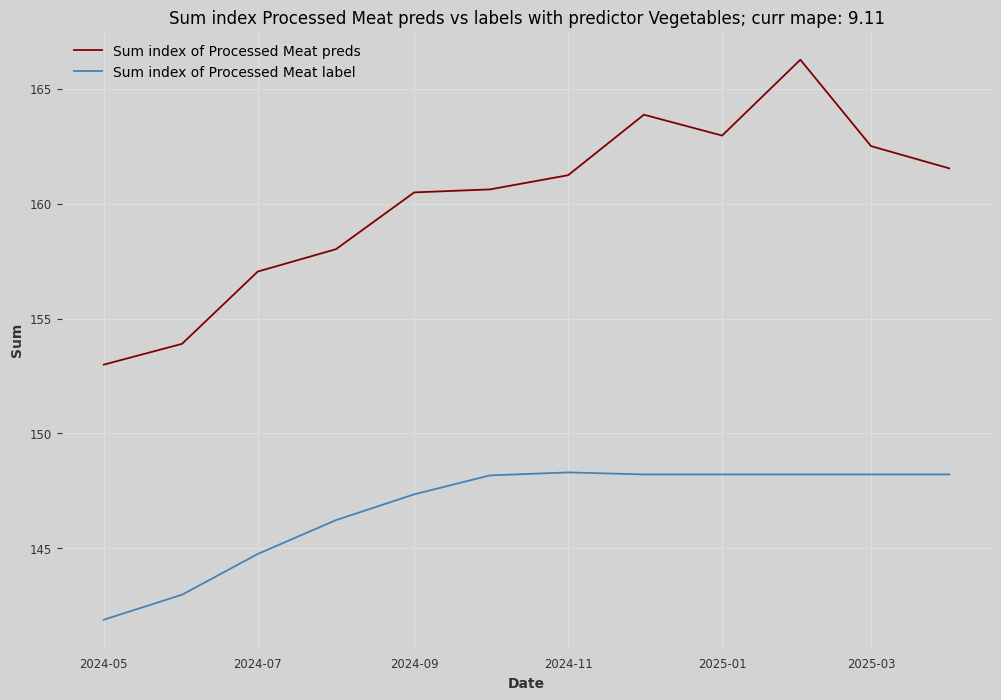

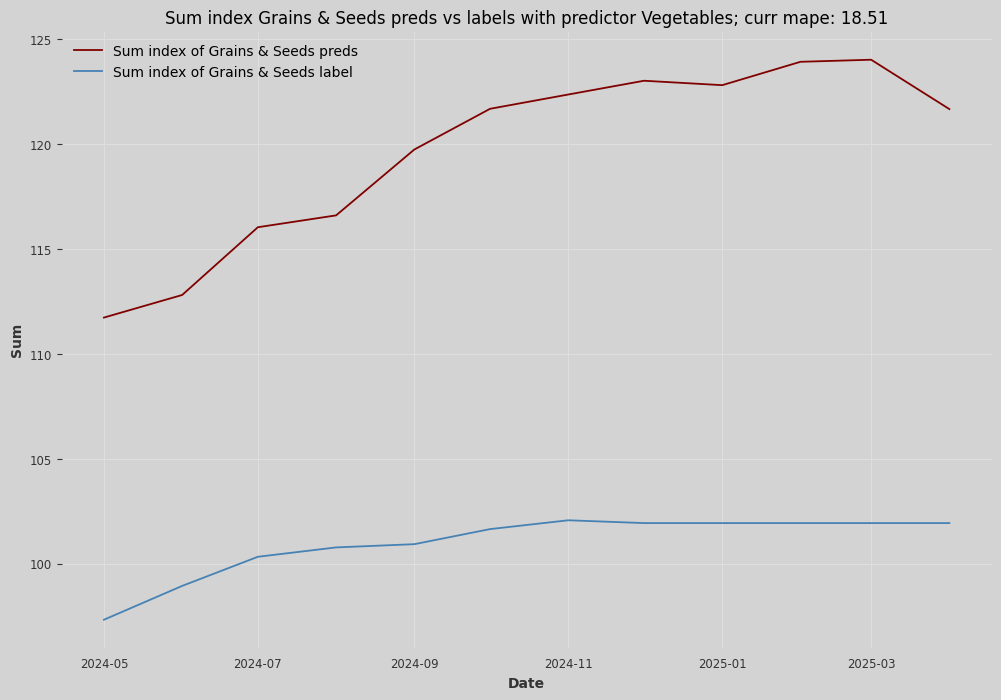

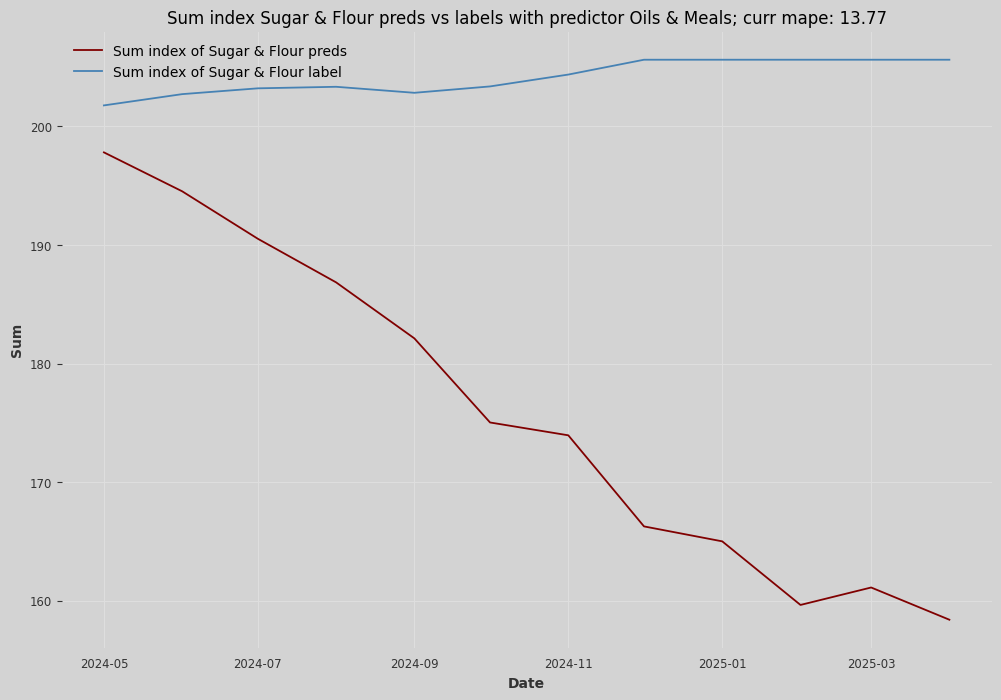

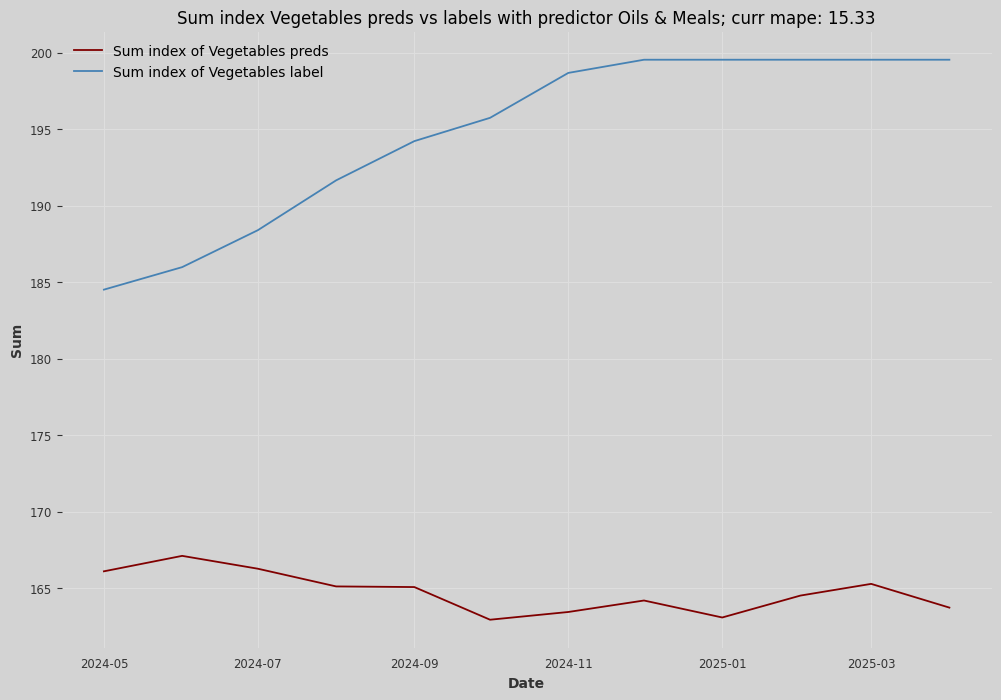

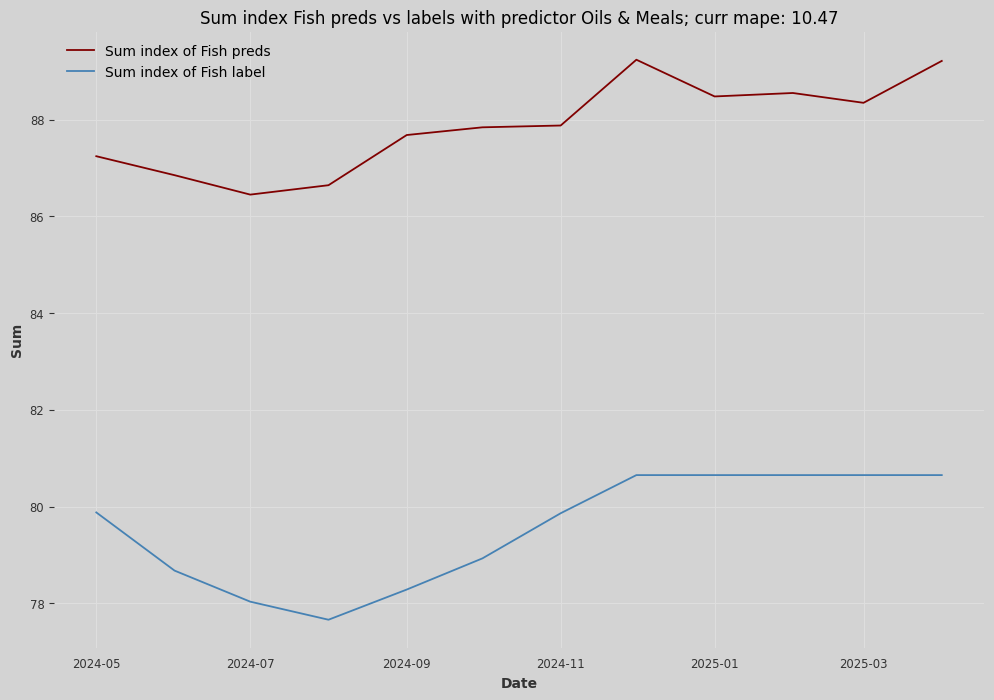

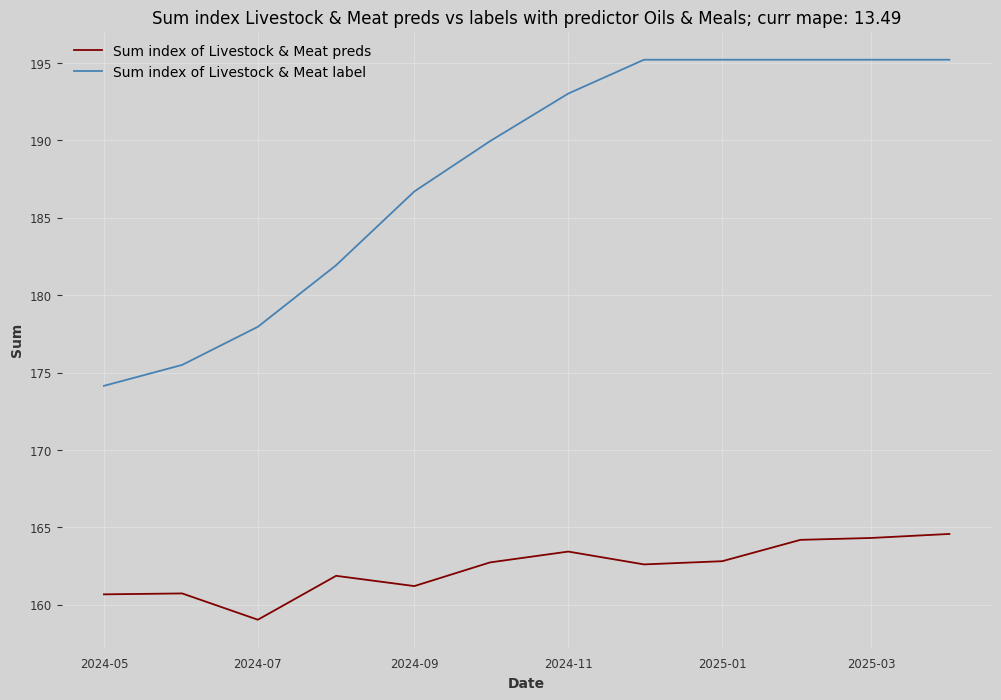

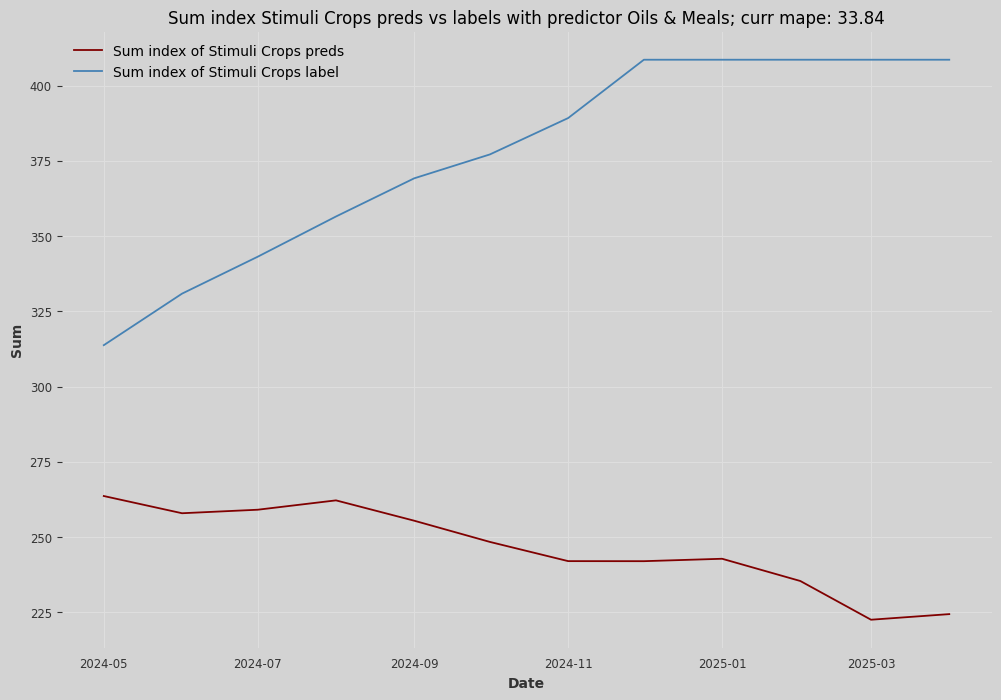

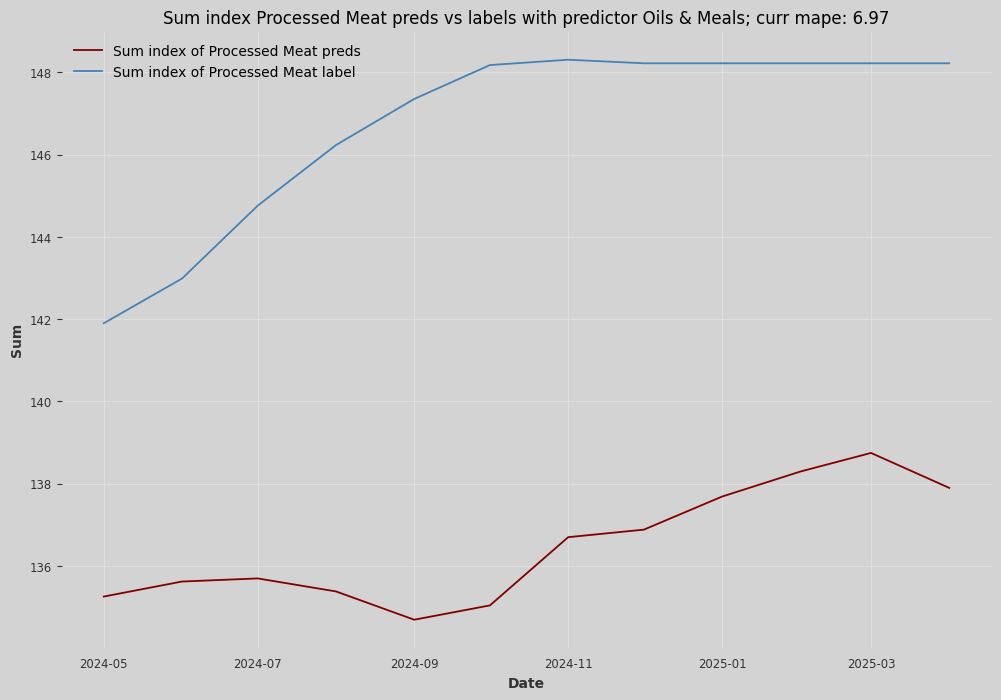

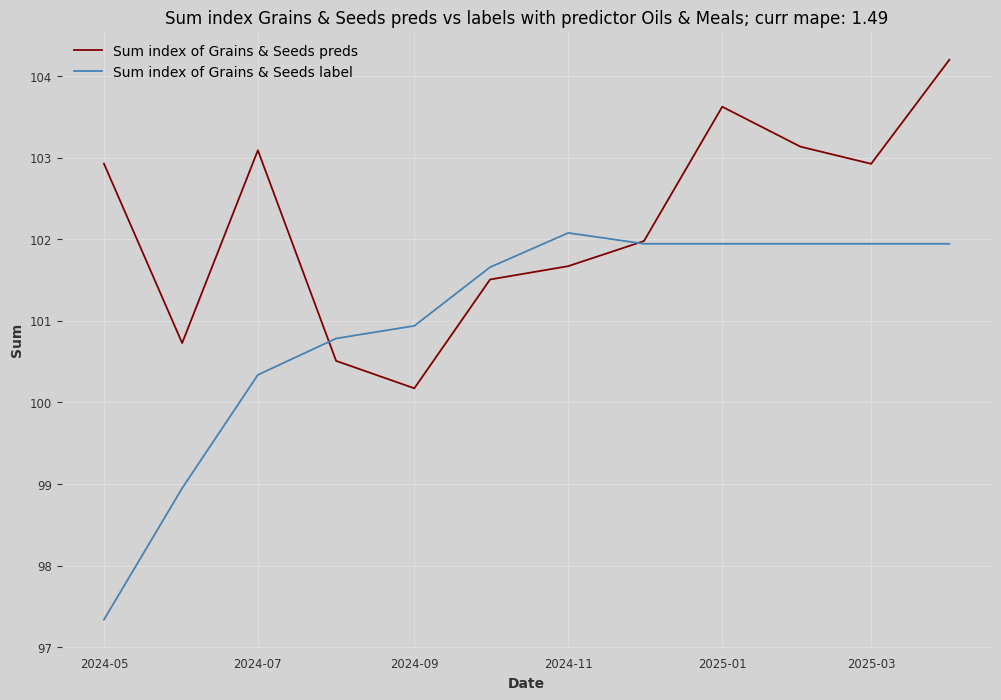

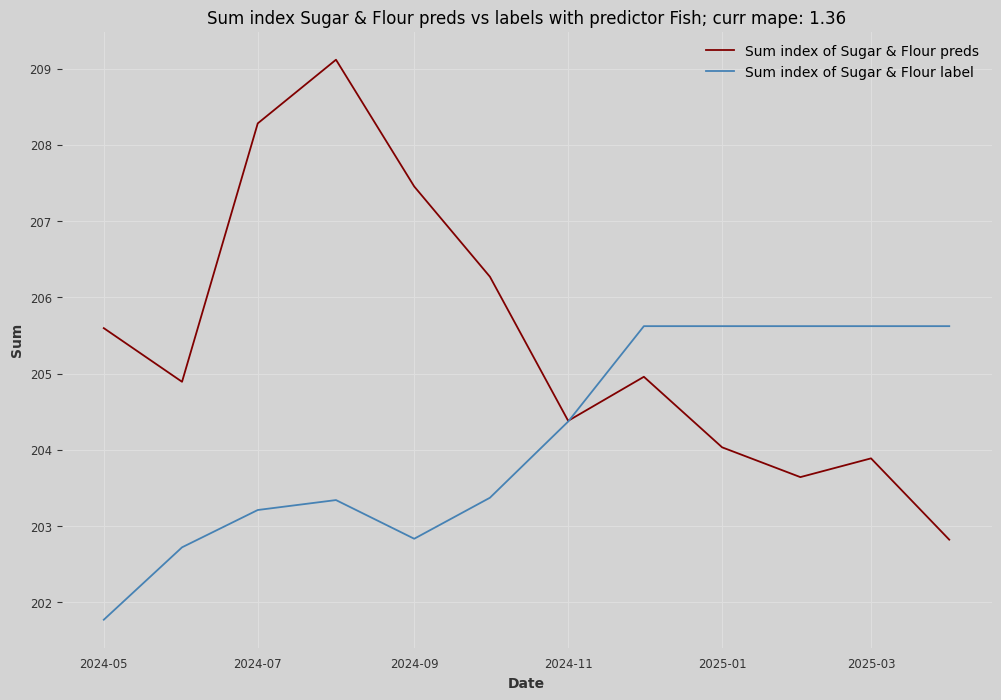

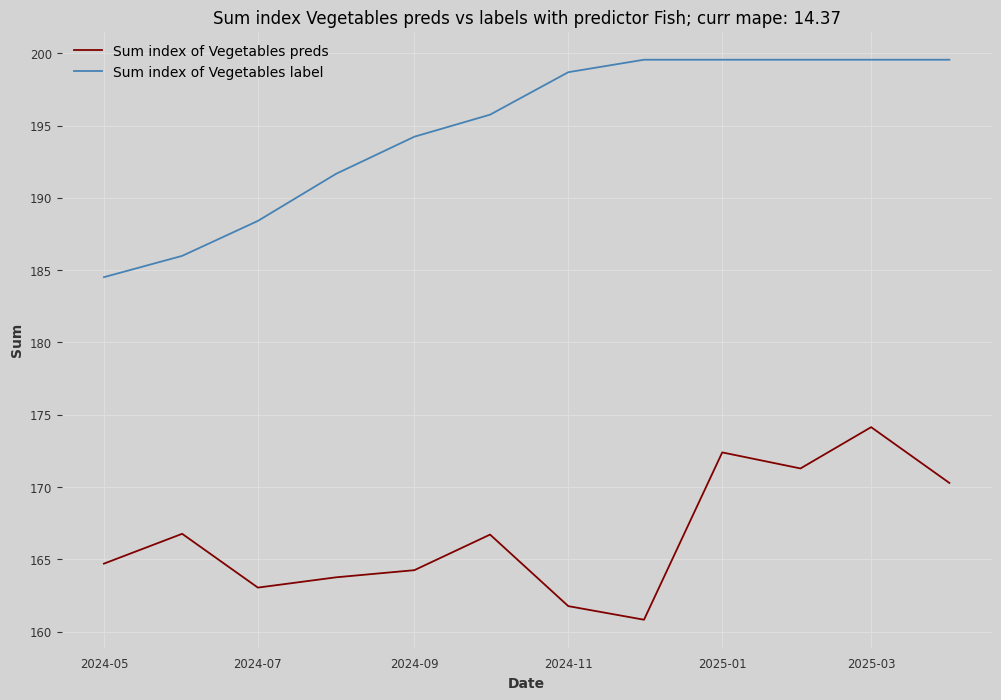

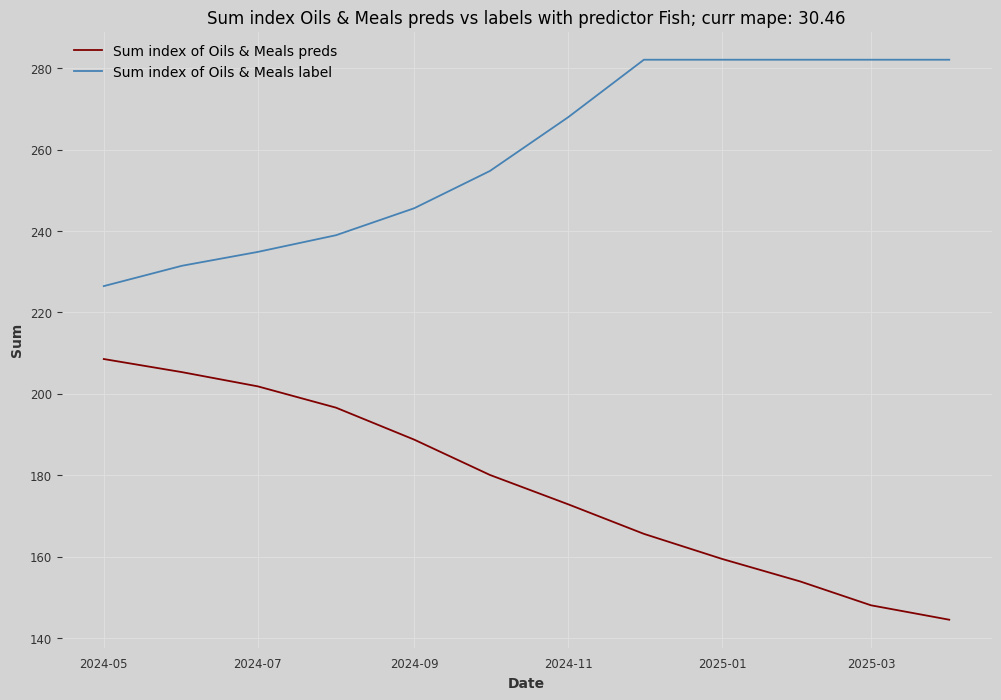

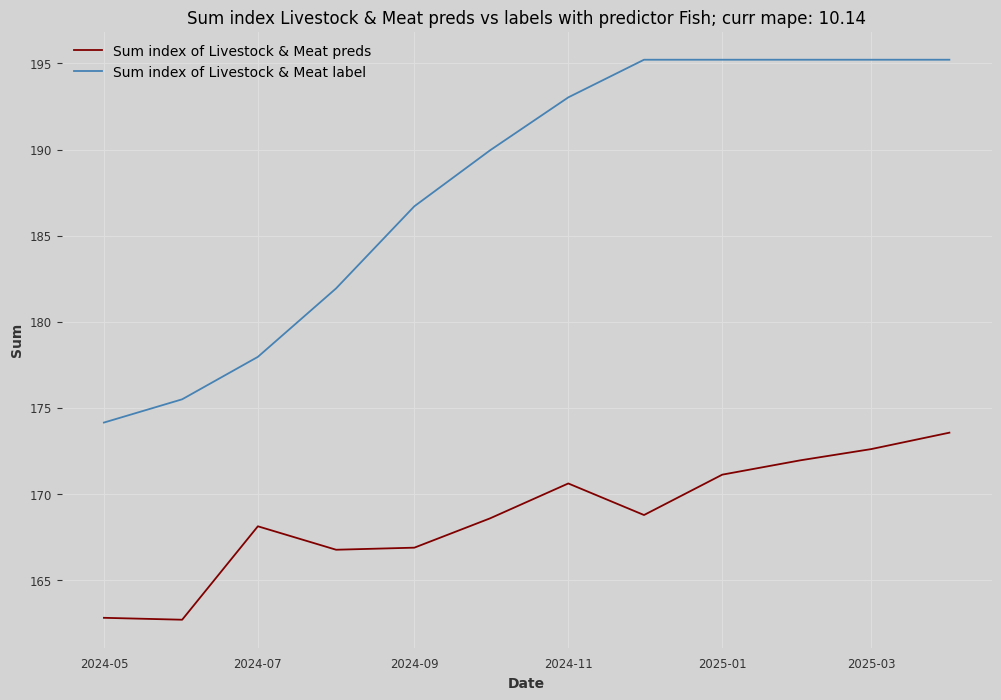

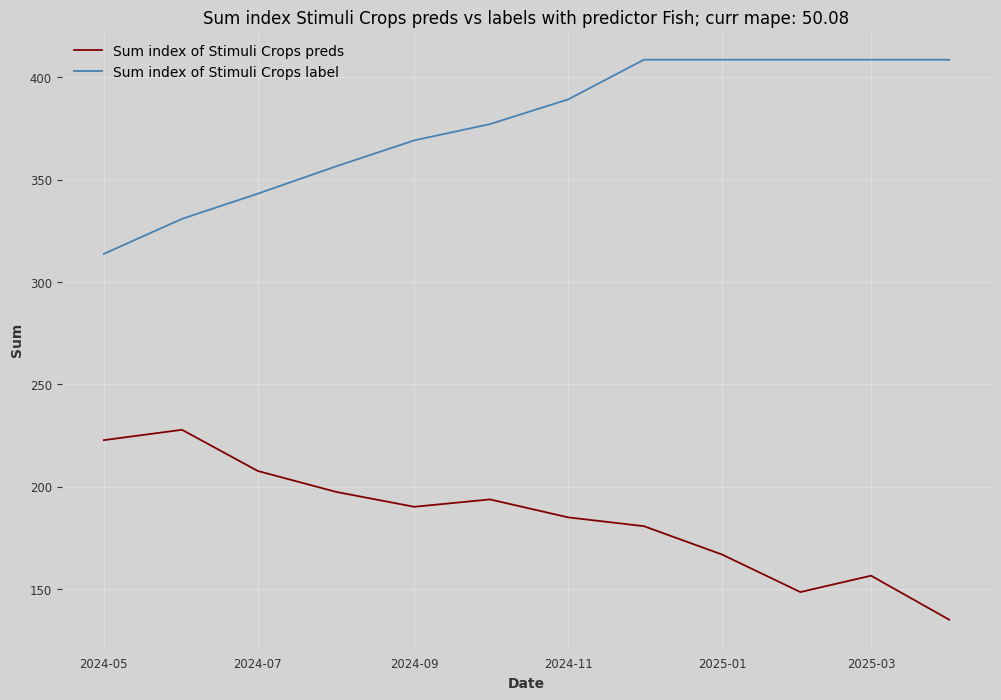

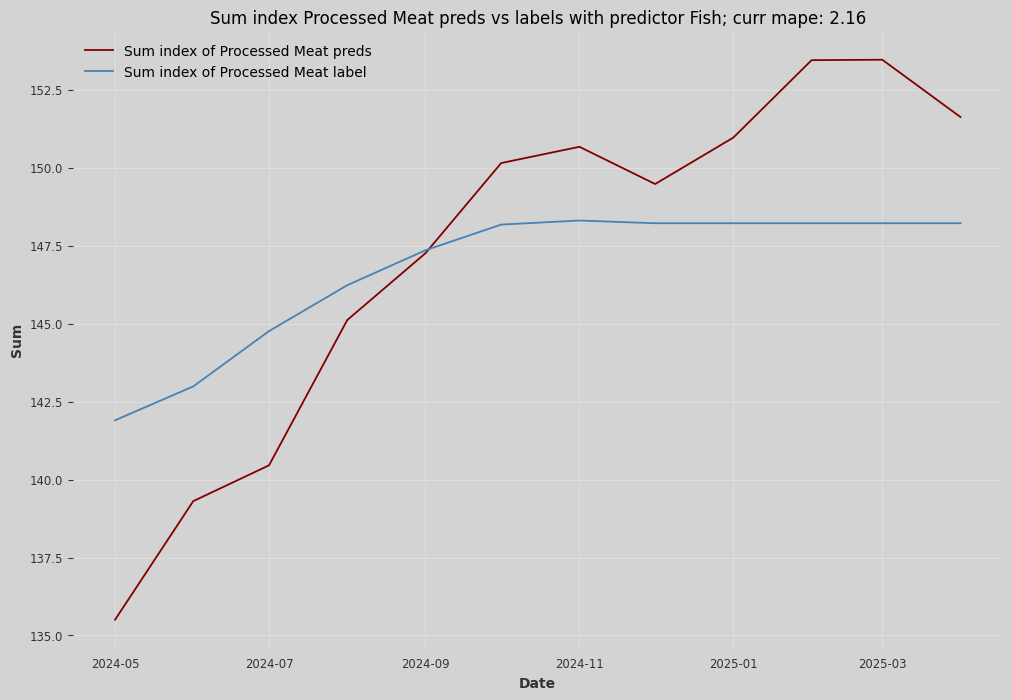

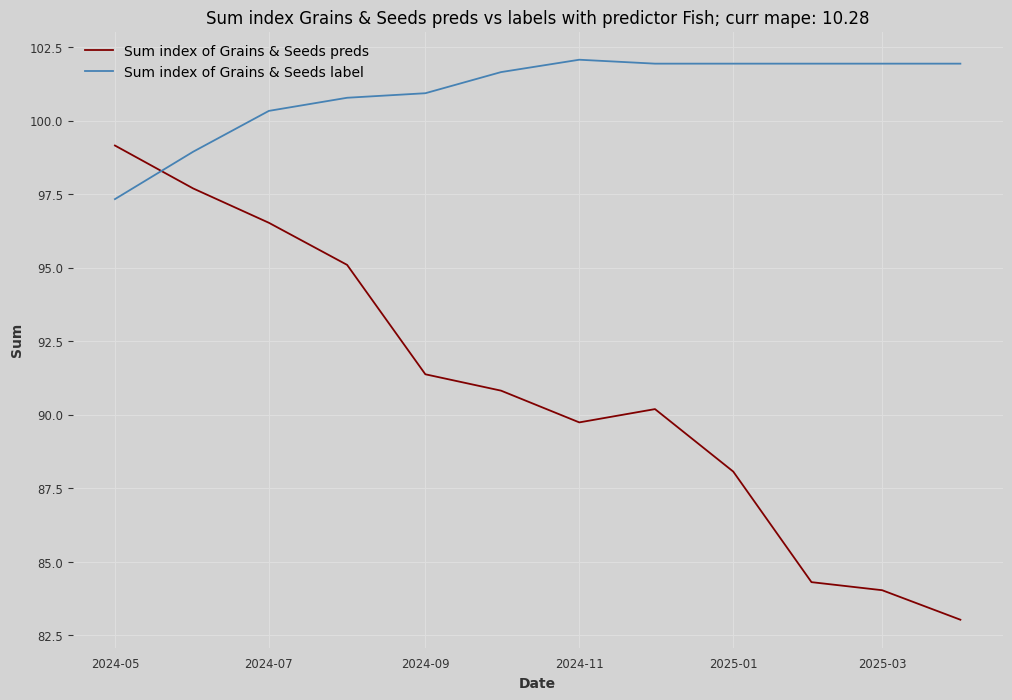

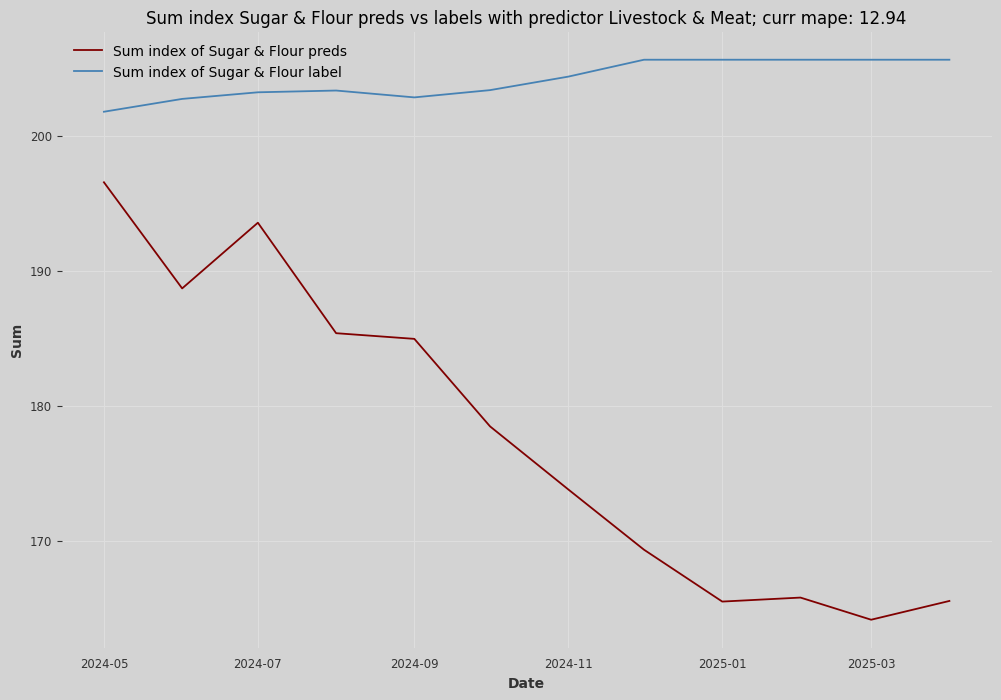

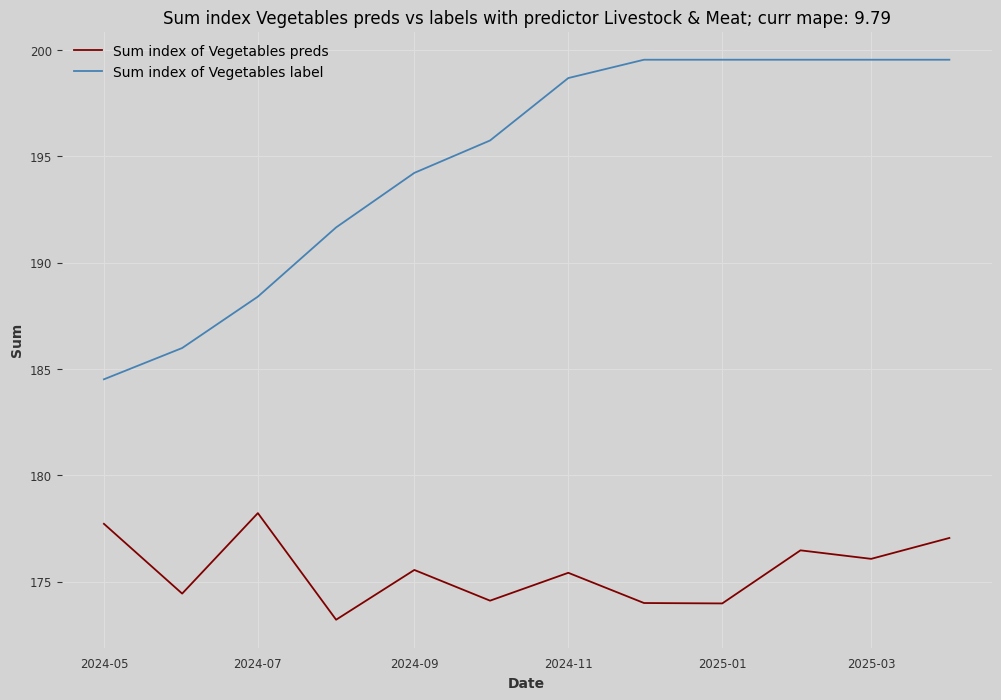

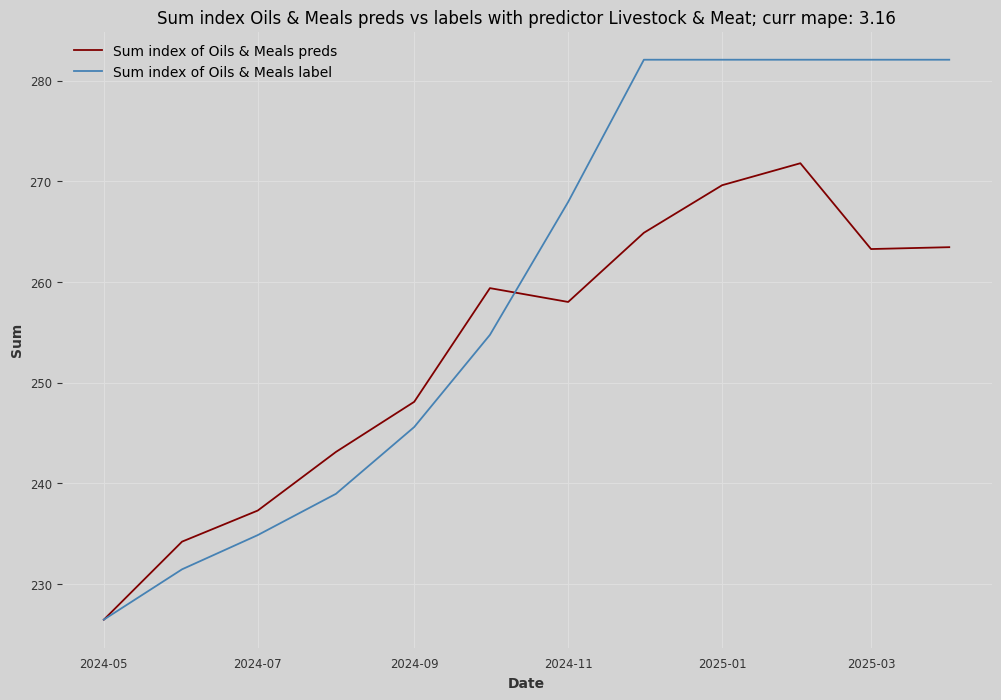

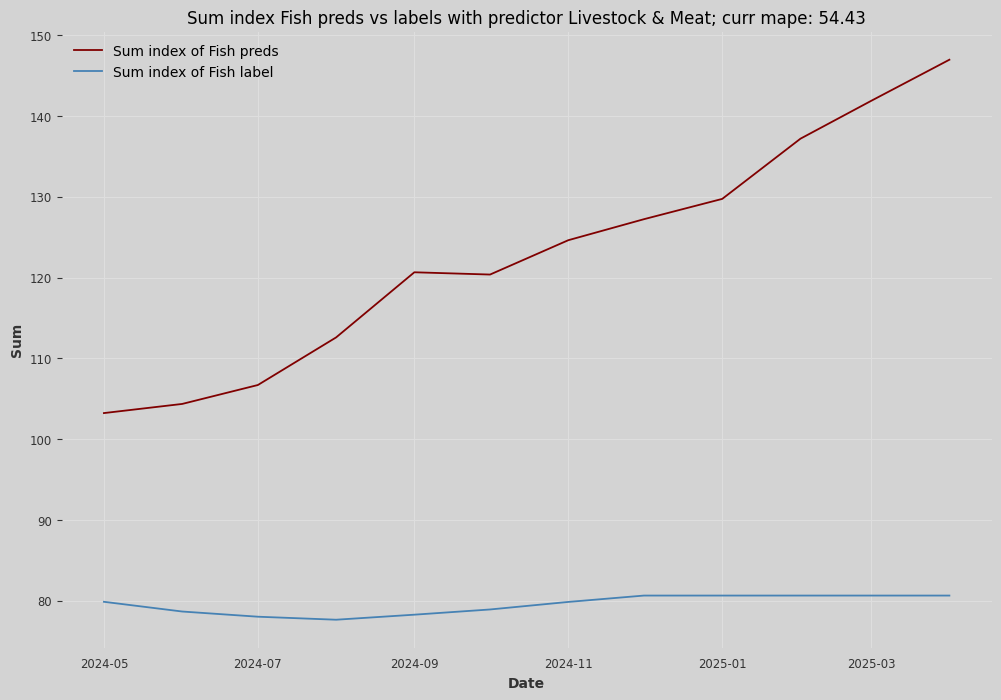

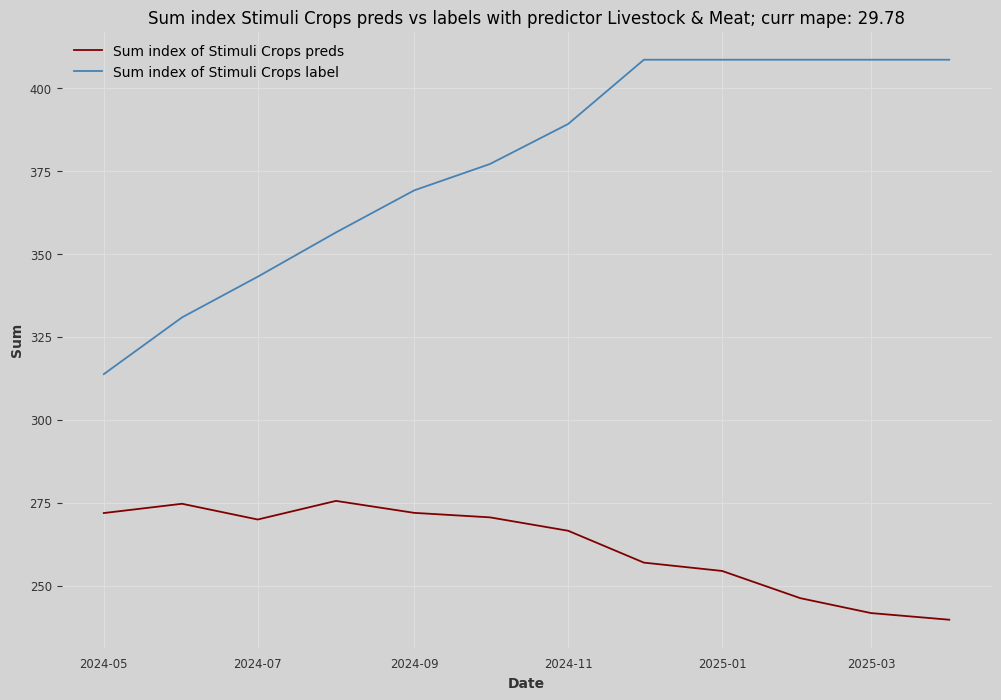

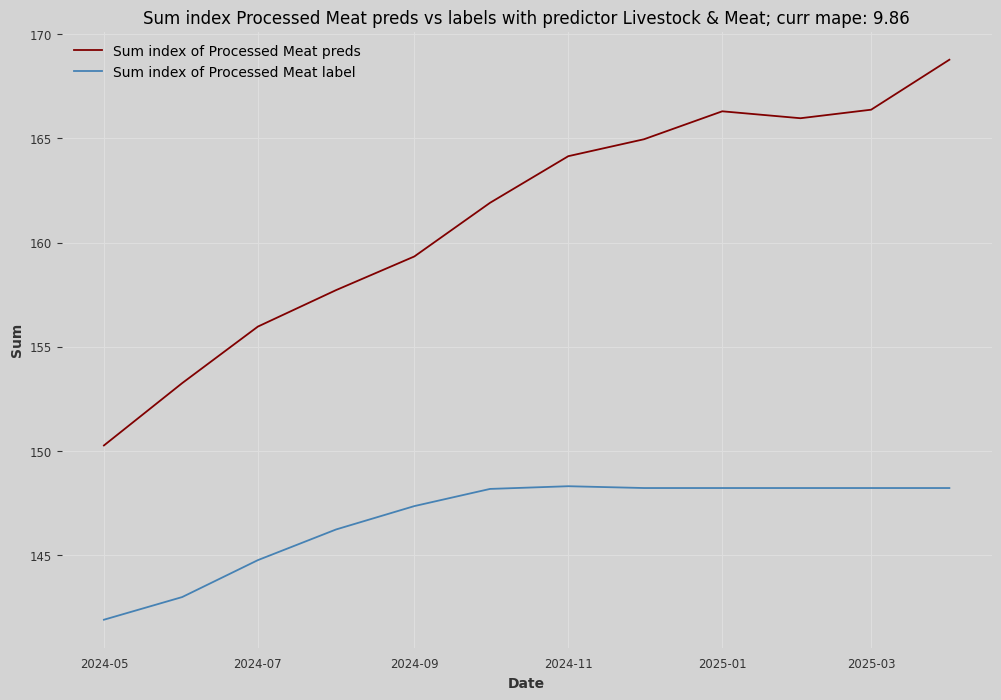

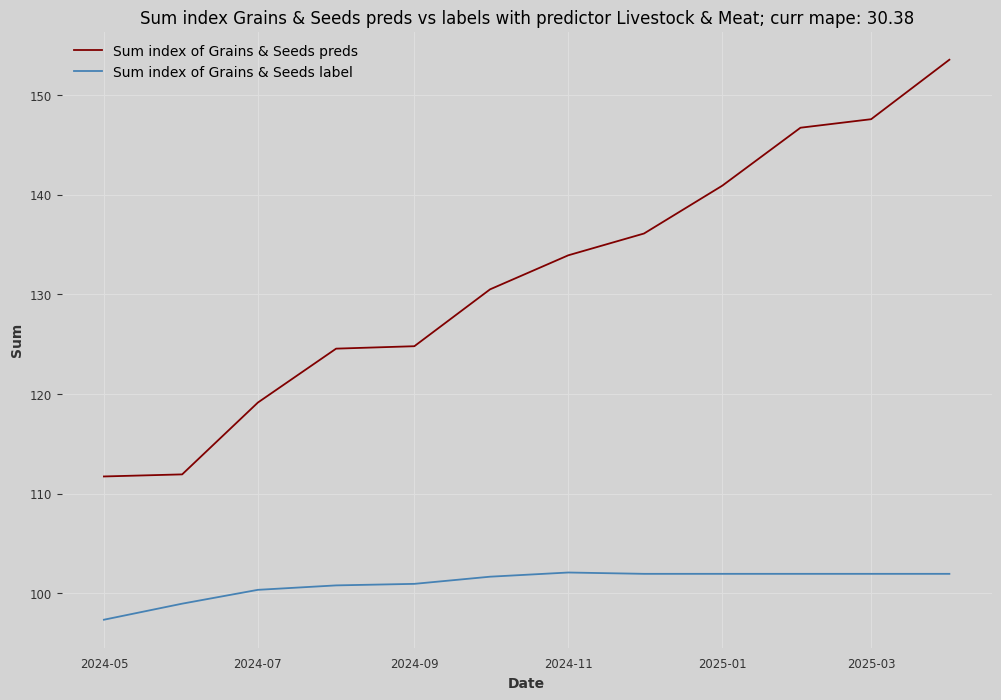

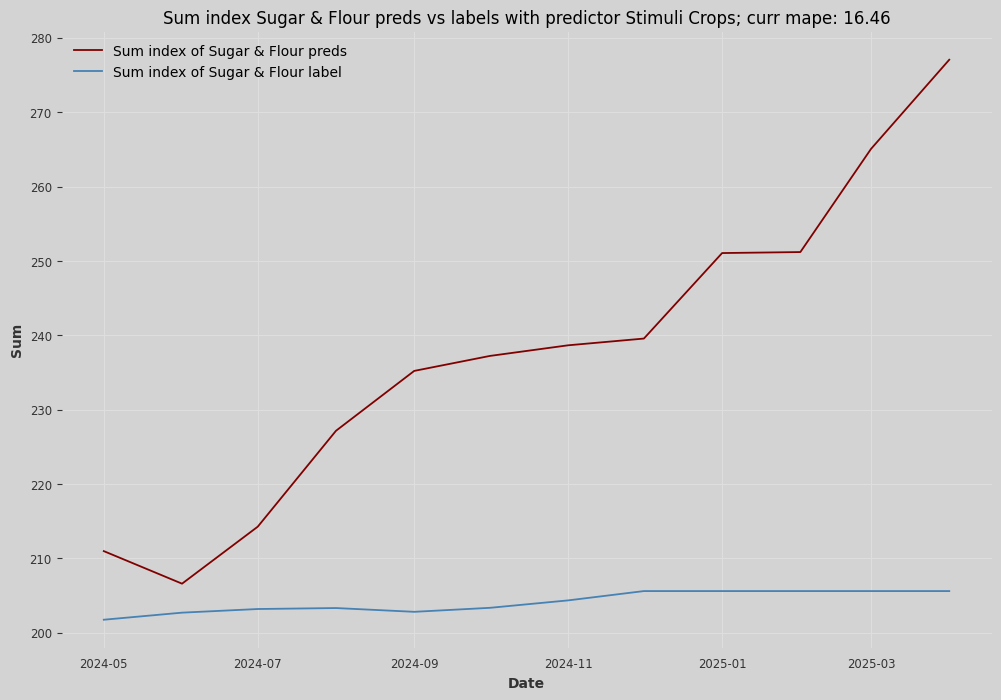

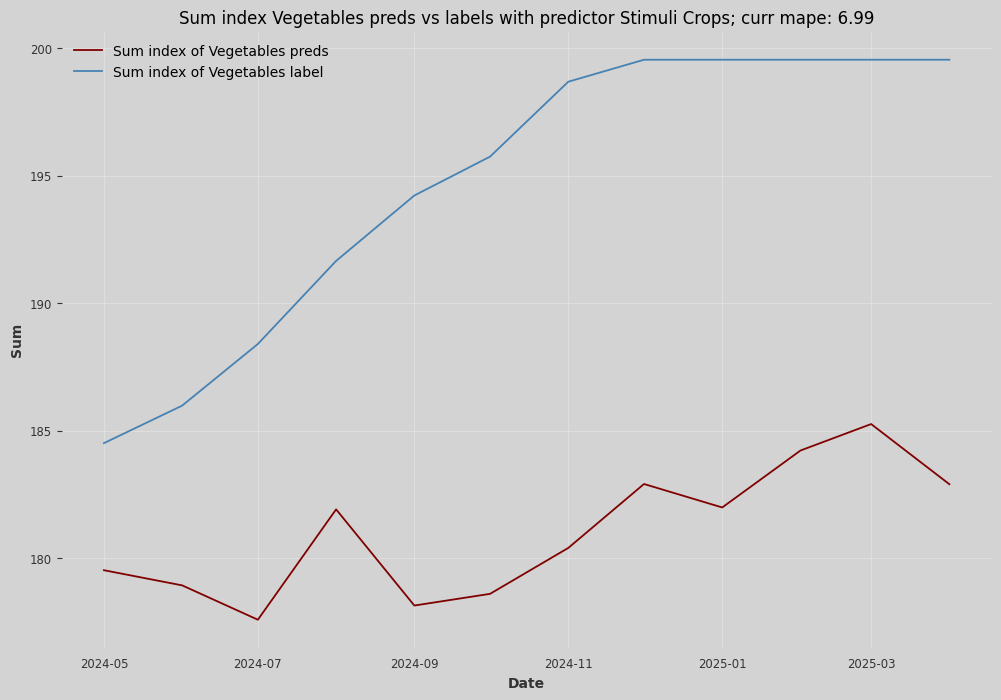

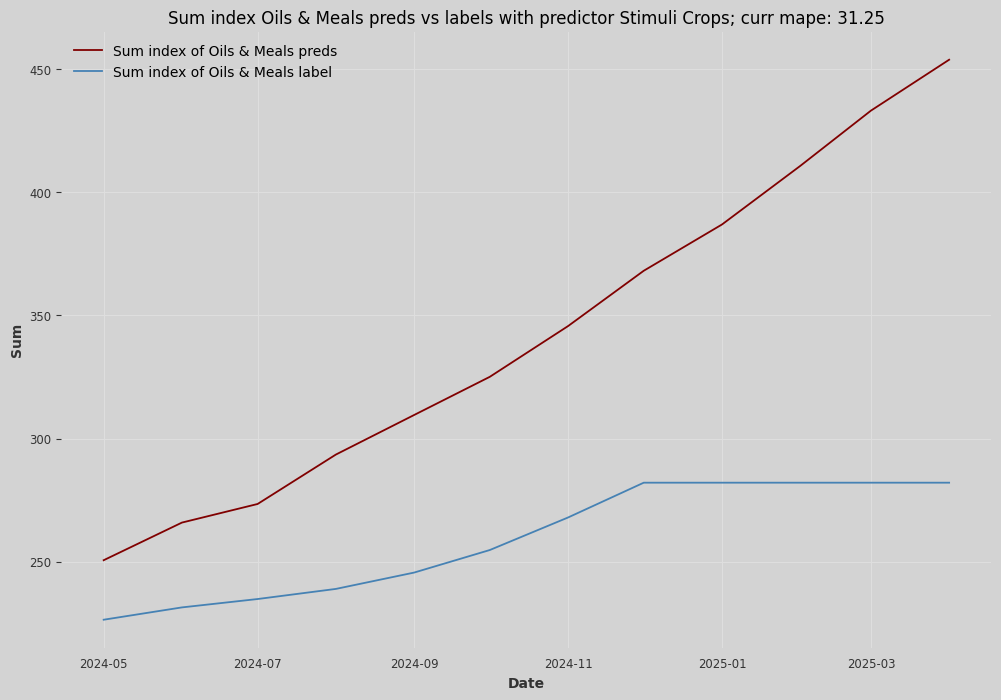

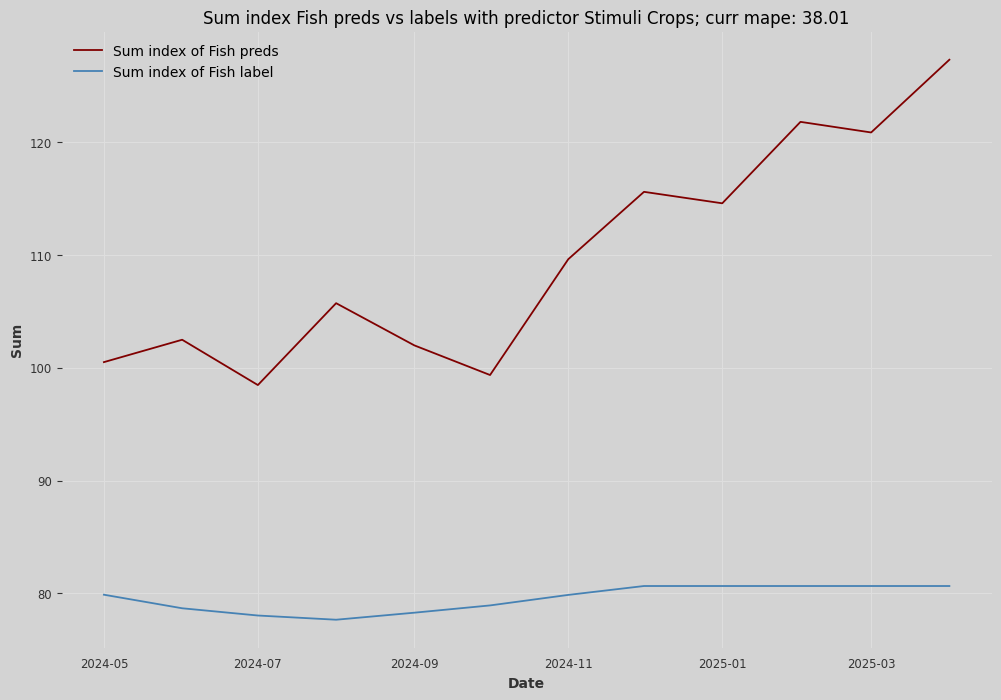

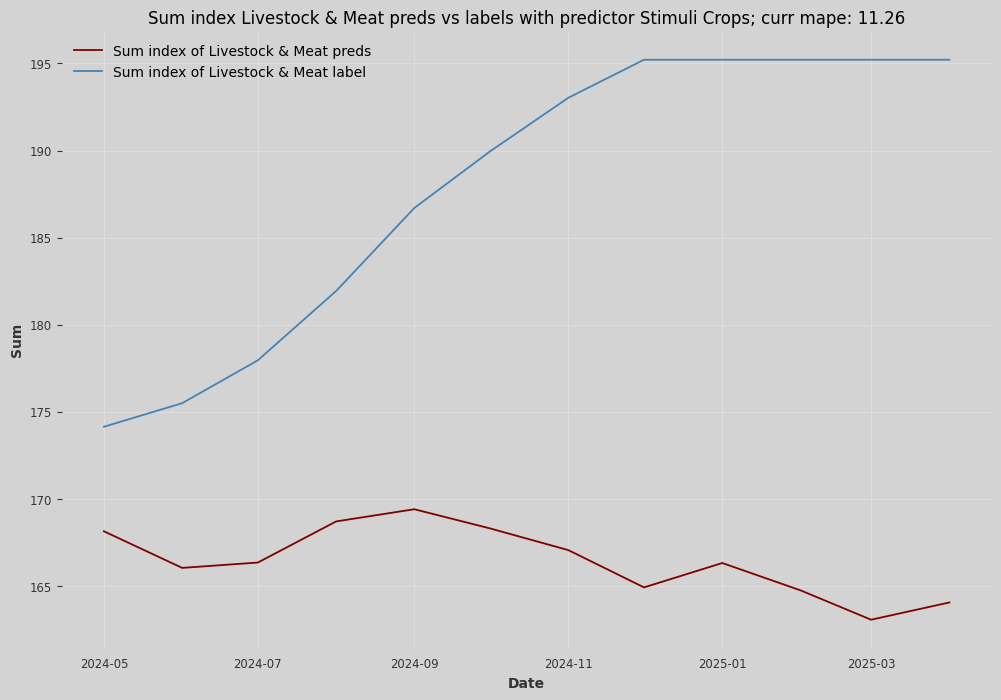

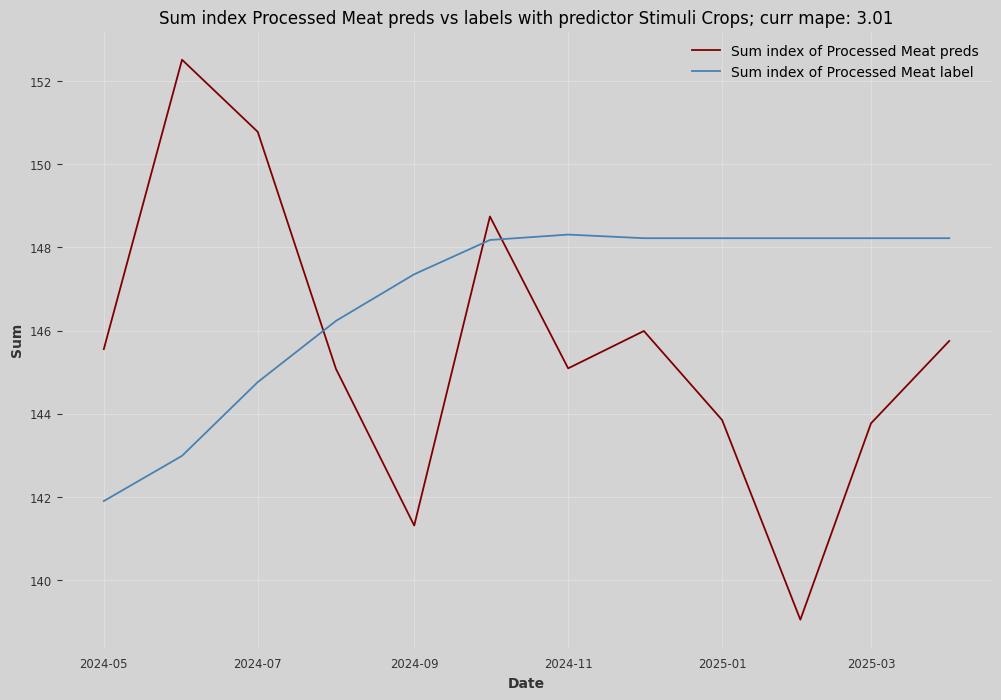

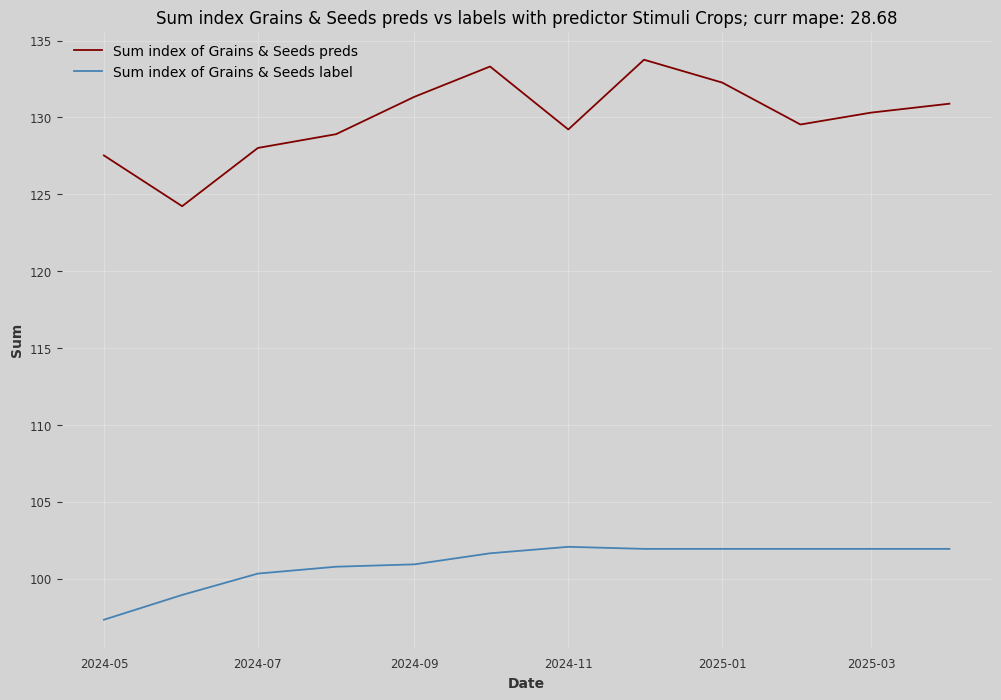

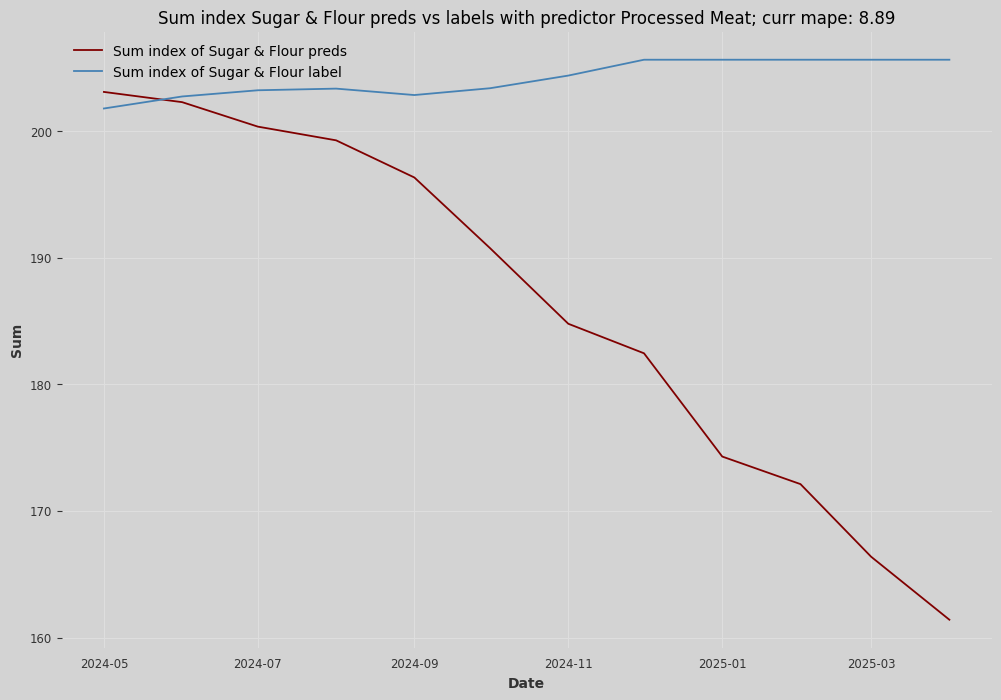

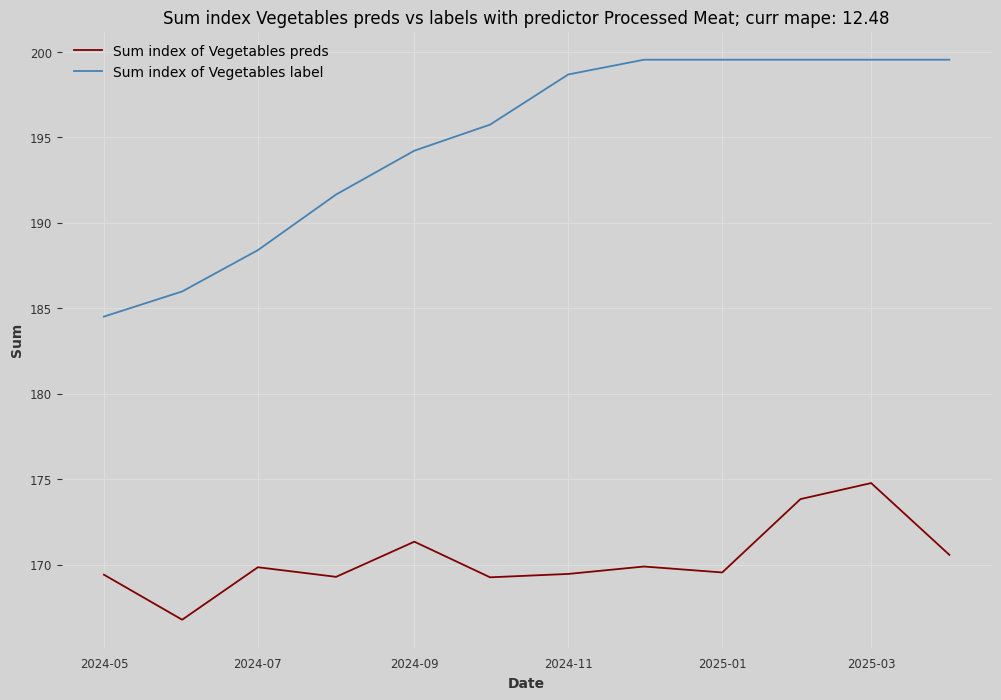

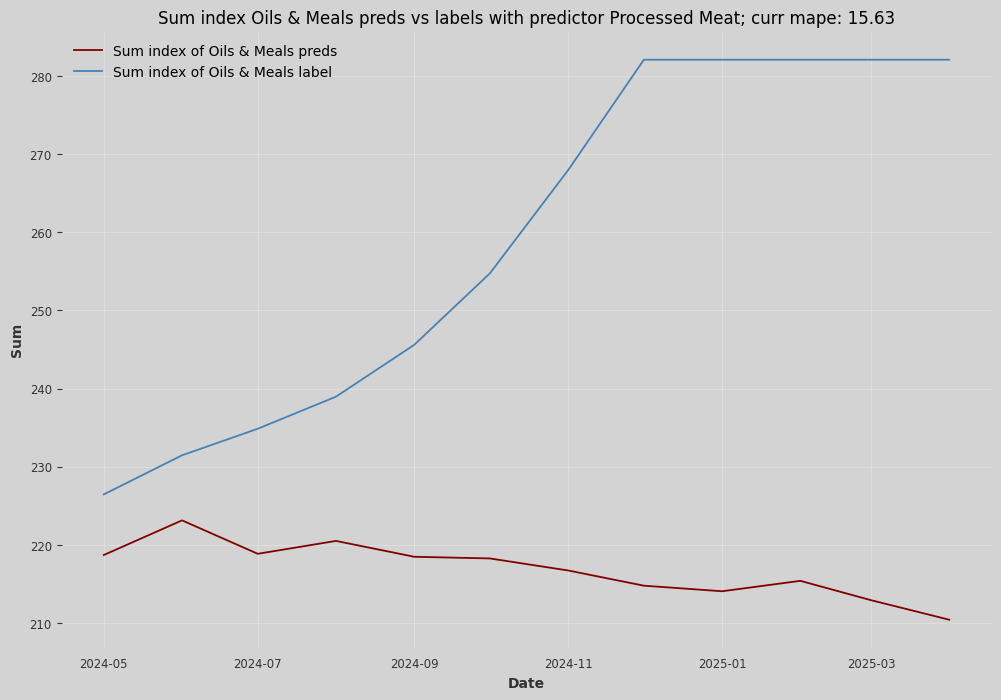

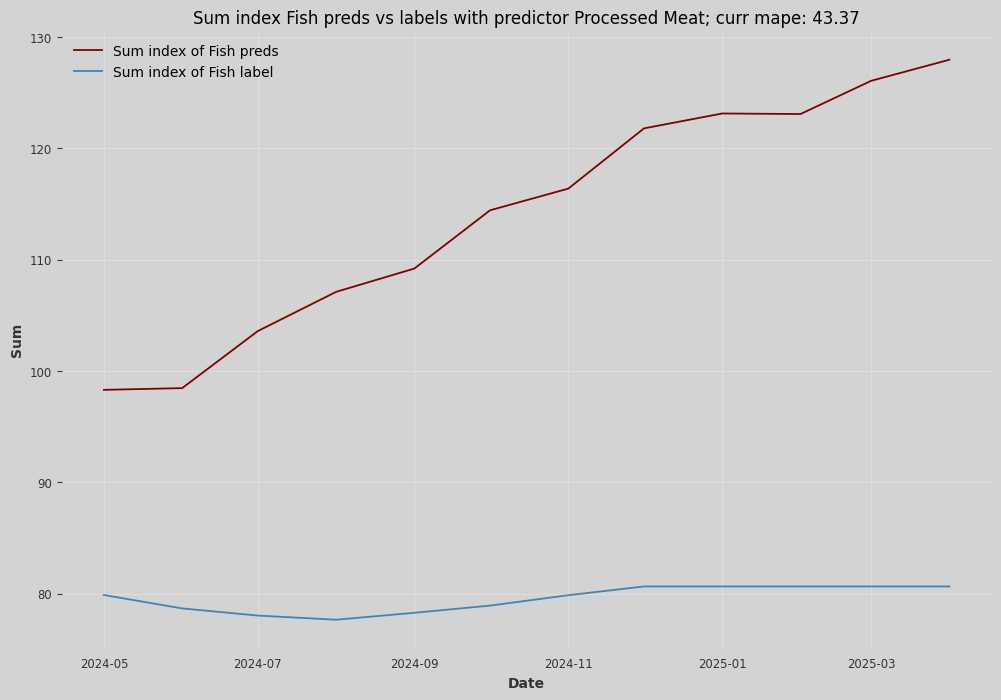

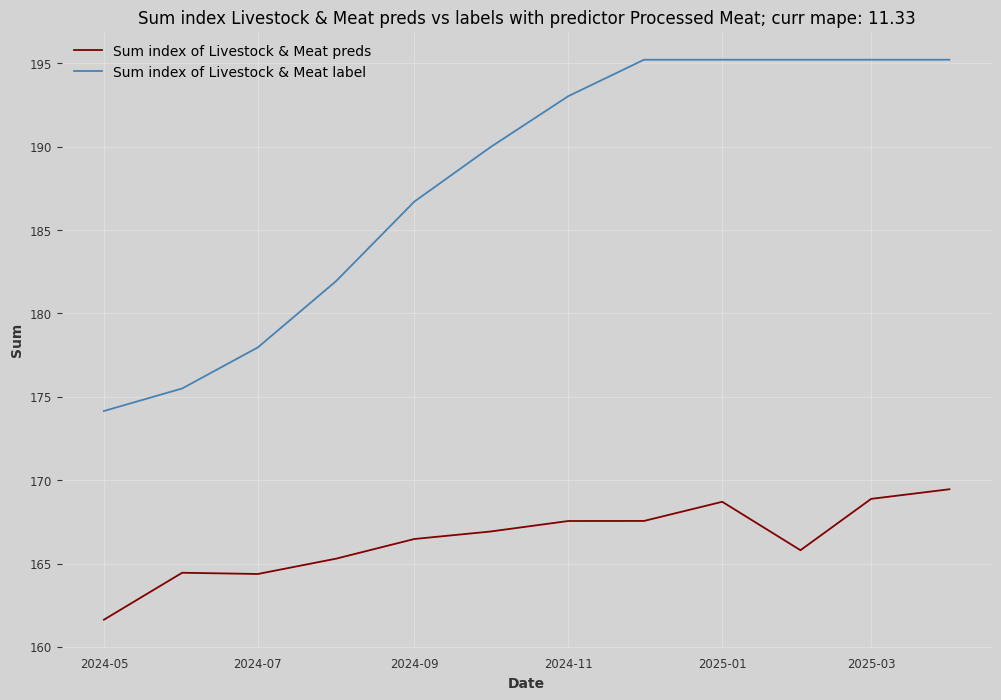

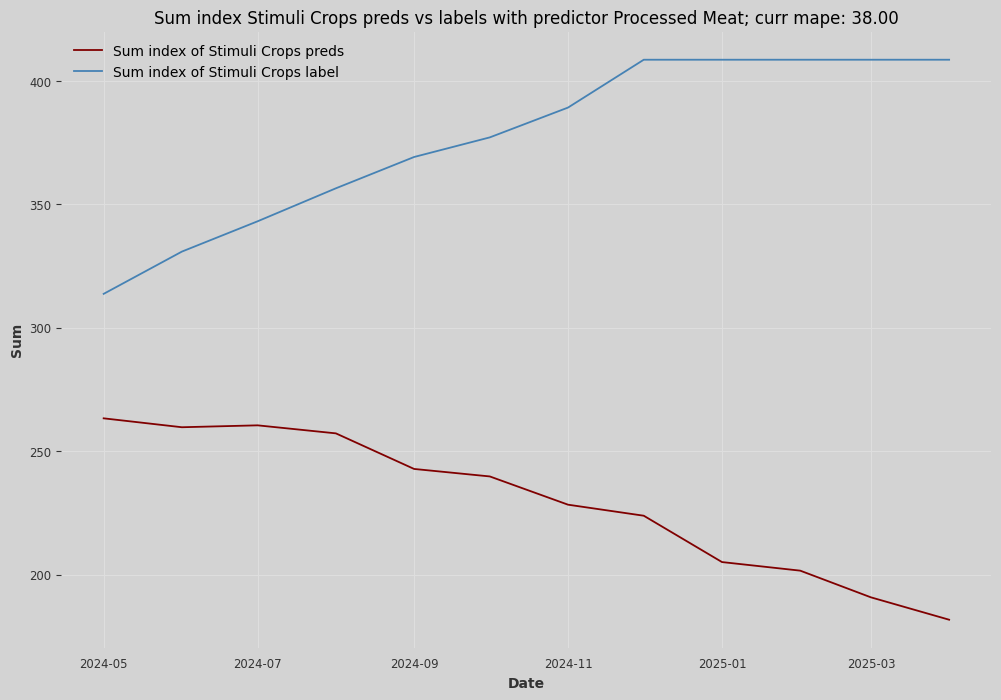

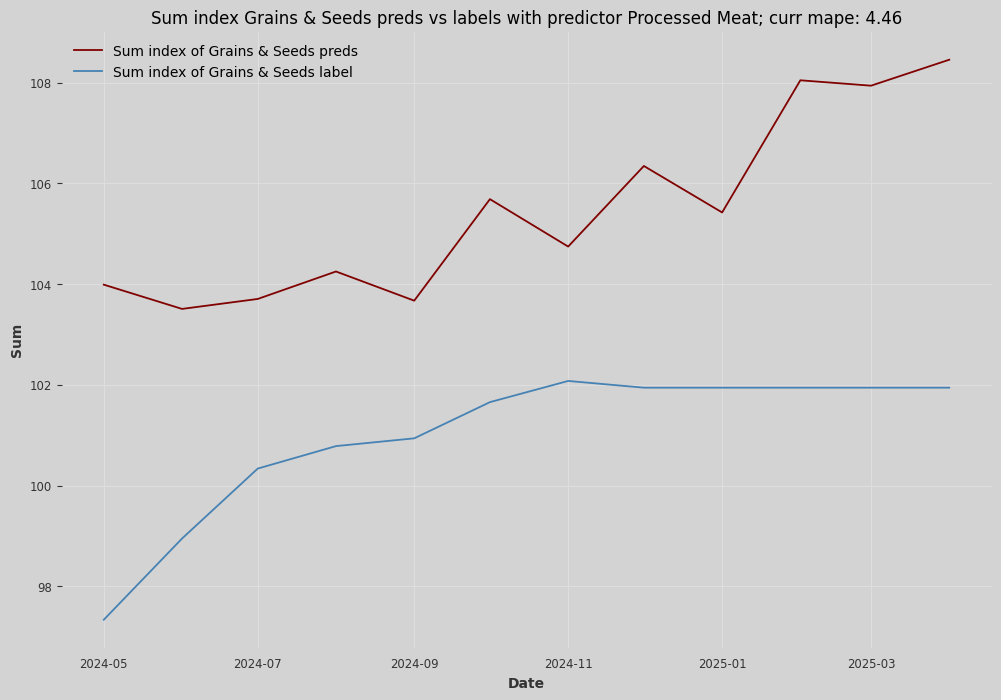

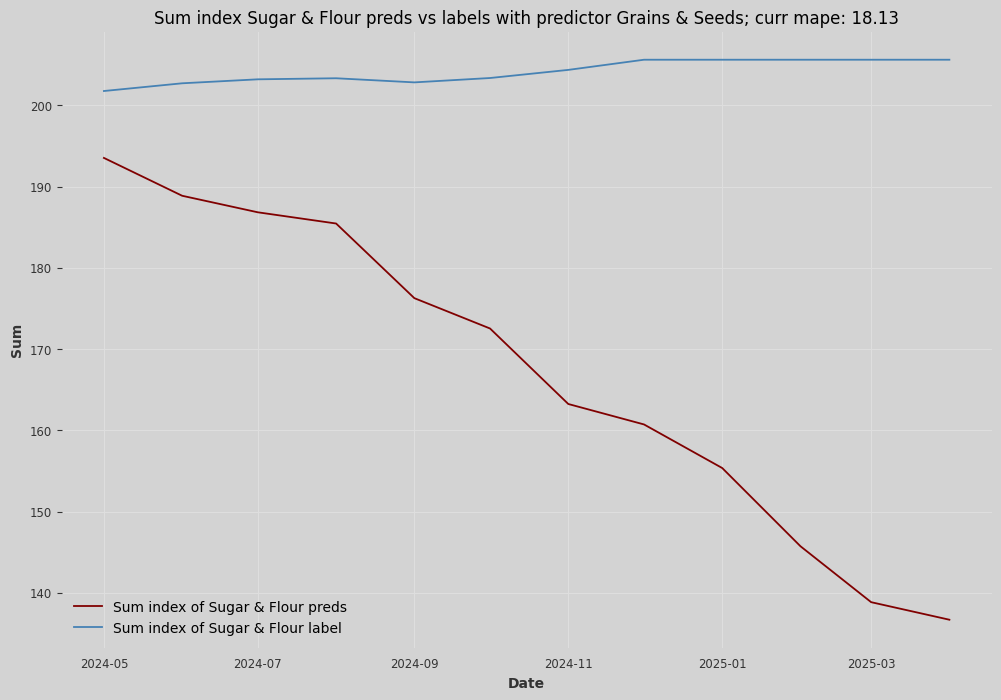

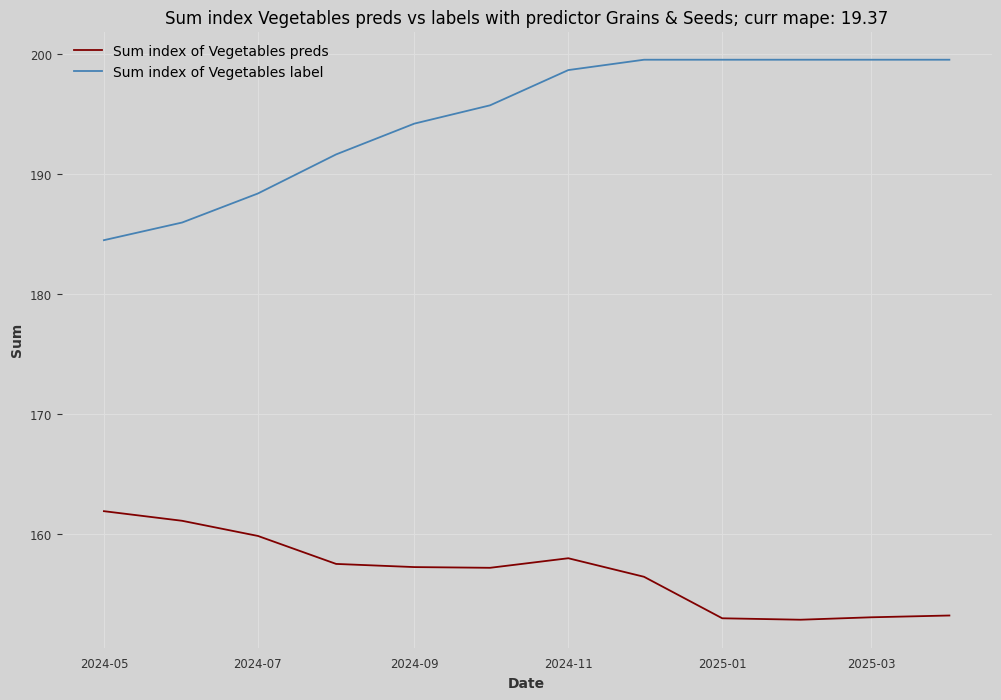

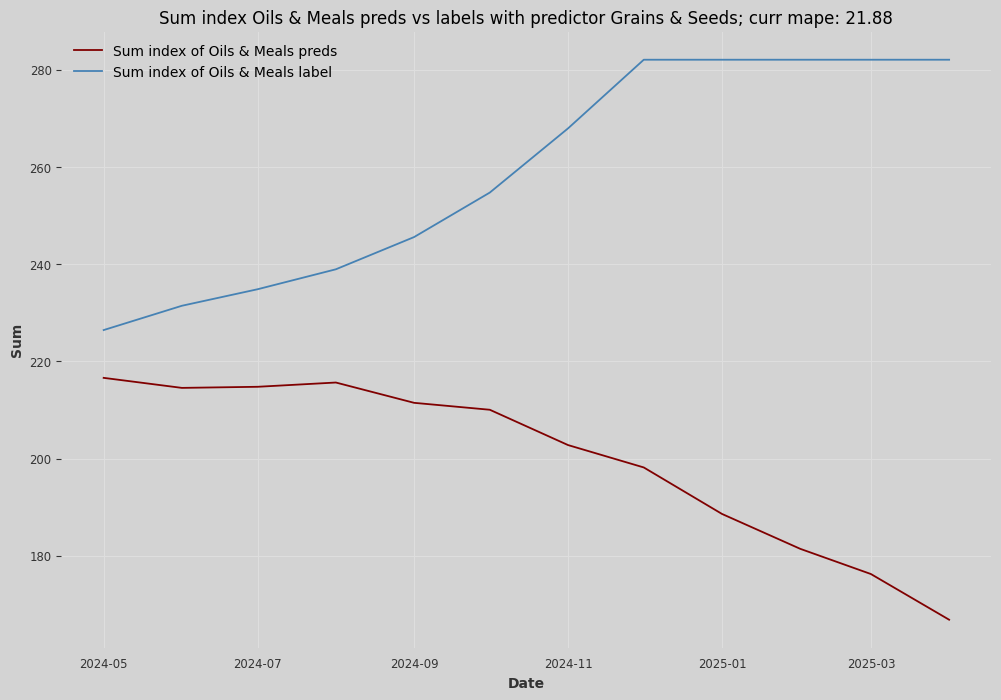

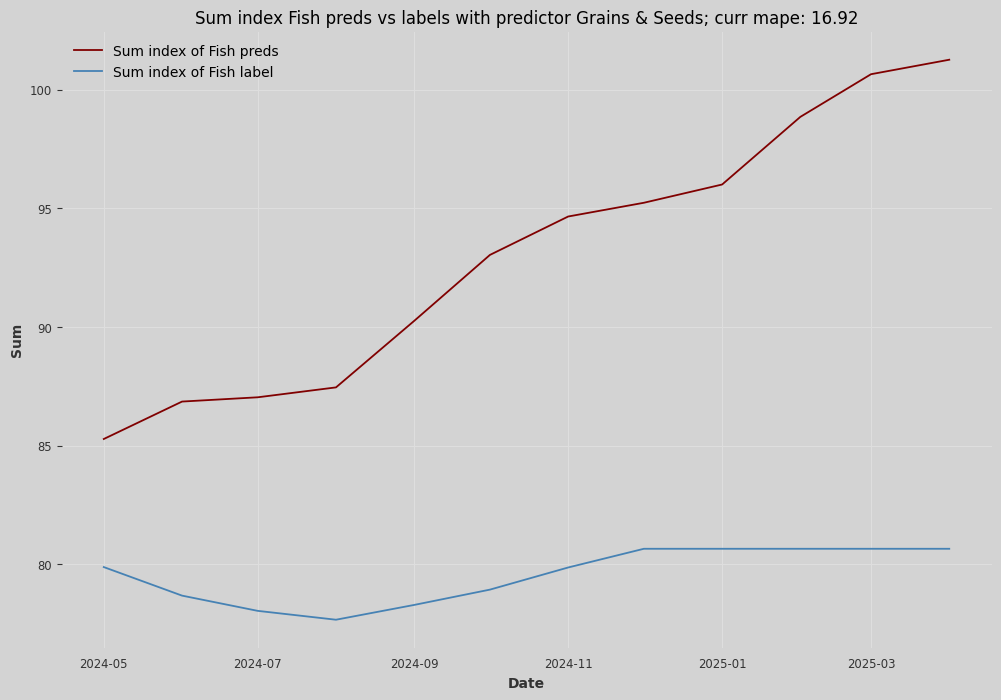

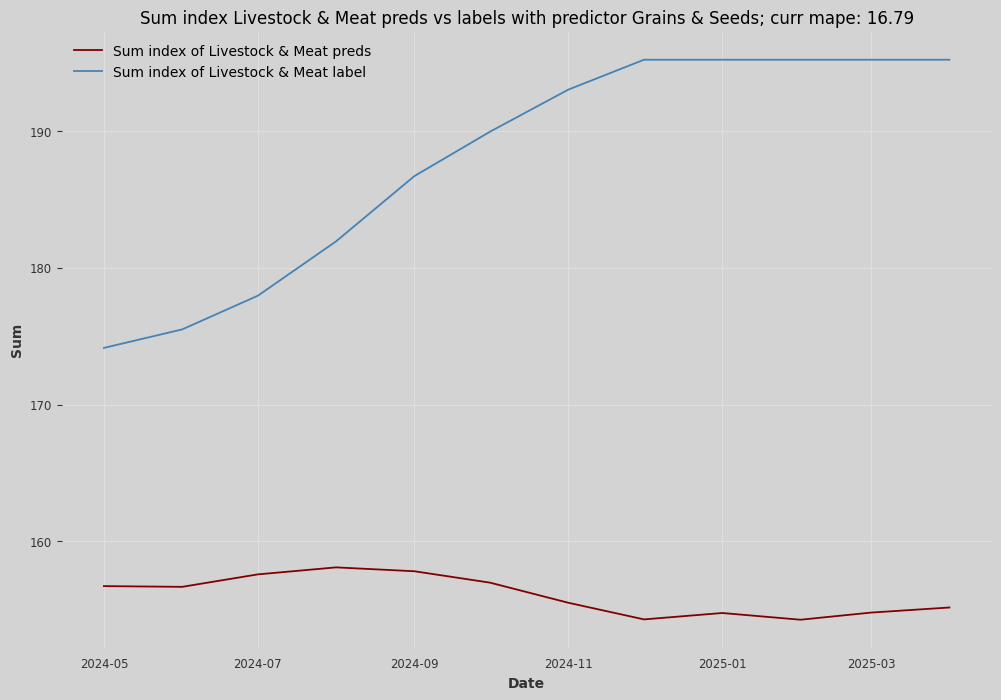

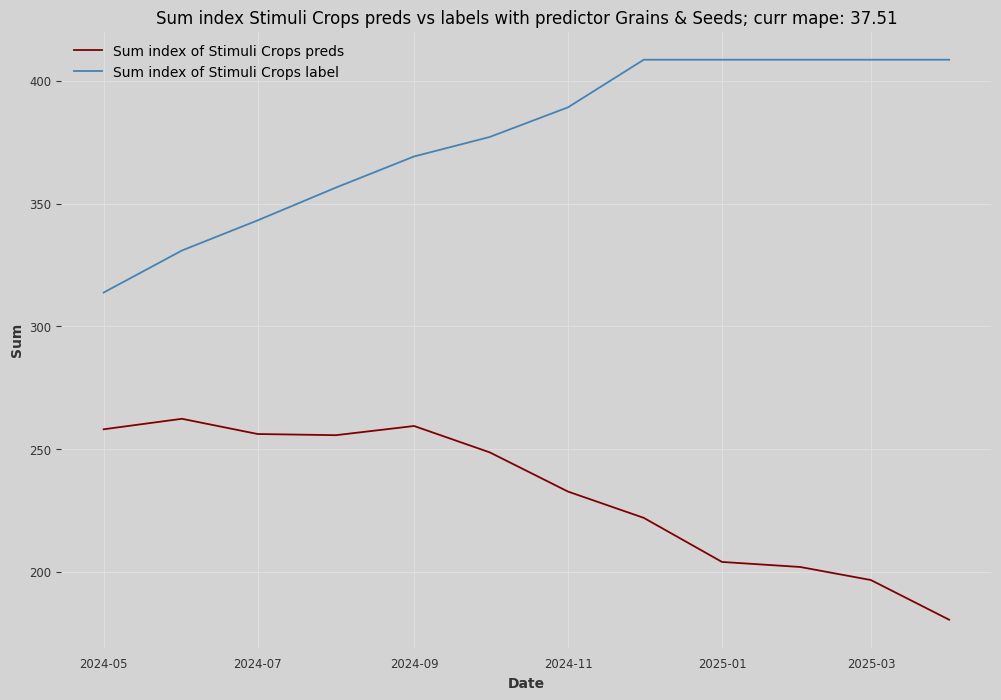

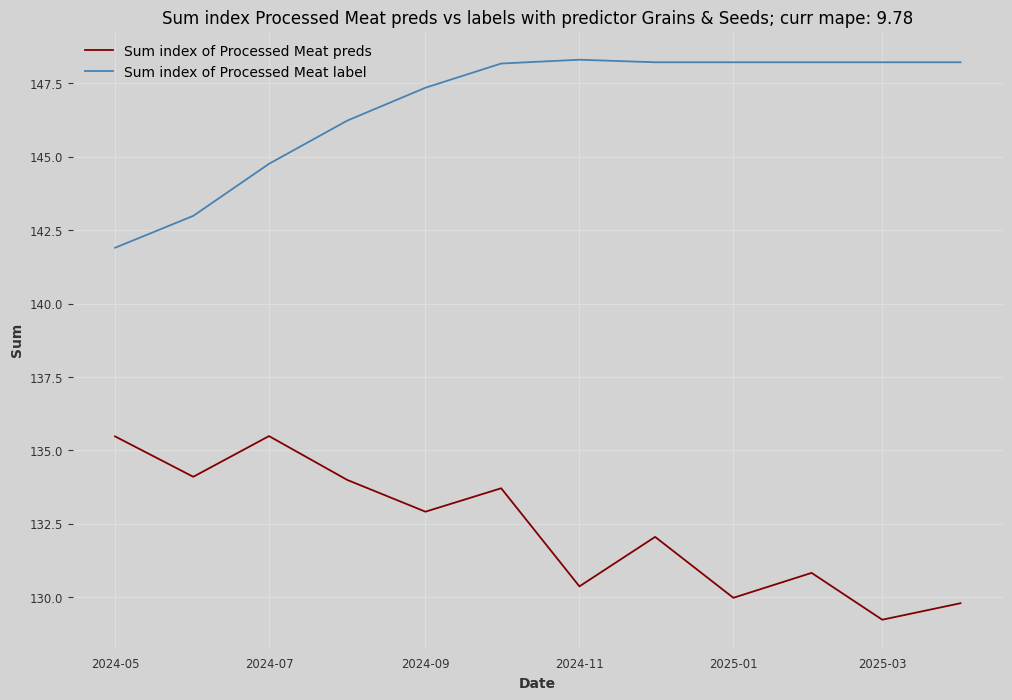

In [137]:
for predictor_cat in set(CATEGORY_MAP.values()):
    for target_cat in set(CATEGORY_MAP.values()):
        if predictor_cat == target_cat:
            continue
        forecaster = ClusterForecaster(cluster_data=apk_nona_en_rol.dropna(),
                                       macro_data=global_macros_en[global_macros_en.index >= apk_nona_en_rol.dropna().index[0]],
                                       category_map=CATEGORY_MAP,
                                       freq="M",
                                       target_col_suffix="_12m_sum",
                                       dir_to_save_plots="darts_result_12_m",
                                       dir_to_save_tables="darts_result_tables_12_m")
        
        start_backtest = pd.Timestamp("2024-05-01")
        
        pred_ts, actual_ts, metrics = forecaster.backtest(
            target_cluster=target_cat,
            additional_cluster=predictor_cat, 
            use_macro=True,
            past_covariate_lags=12,
            start_backtest=start_backtest,
            forecast_horizon=12, 
            model_type="NBEATS",
            n_epochs=200
        )

        print("Metrics:", metrics)

---
## Go trough triplets

In [152]:
CAT_MAP_ENCODING = {
 'Sugar & Flour': 0,
 'Vegetables': 1,
 'Oils & Meals': 2,
 'Fish': 3,
 'Livestock & Meat': 4,
 'Stimuli Crops': 5,
 'Processed Meat': 6,
 'Grains & Seeds': 7
}

In [163]:
def plot_preds_on_curve(preds: pd.DataFrame,
                        label: pd.DataFrame,
                        mape_val: str,
                        predictor_name: str|list[str],
                        cat_name: str,
                        save_dir: str):
    pred_names = "+".join([str(CAT_MAP_ENCODING[pred_name]) for pred_name in predictor_name]) if isinstance(predictor_name, list) else predictor_name
        
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('lightgray')
    ax.plot(preds.index, preds, color="maroon", label=f"Sum index of {cat_name} preds")
    ax.plot(label.index, label, color="steelblue", label=f"Sum index of {cat_name} label")
    ax.legend()
    ax.set_title(f"Sum index {cat_name} preds vs labels with predictor {"|".join(predictor_name)}; curr mape: {mape_val:.2f}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sum")
    ax.set_facecolor('lightgray')
    plt.savefig(f'{save_dir}/{cat_name}_by_{pred_names}_sum_index_one_year.png')

In [166]:
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, mae, rmse
import pandas as pd
from typing import Dict, Optional


class ClusterForecaster:
    def __init__(self,
                 cluster_data: pd.DataFrame,
                 macro_data: pd.DataFrame,
                 category_map: Dict[str, str],
                 freq: str = "M",
                 target_col_suffix: str = "_sum",
                 dir_to_save_plots: str = "darts_result",
                 dir_to_save_tables: str = "darts_result_tables"):
        self.cluster_data = cluster_data
        self.macro_data = macro_data
        self.category_map = category_map
        self.freq = freq
        self.scaler_target = Scaler()
        self.scaler_cov = Scaler()
        self.model = None
        self.target_col_suffix = target_col_suffix
        self.dir_to_save_plots = dir_to_save_plots
        self.dir_to_save_tables = dir_to_save_tables

    def _aggregate_clusters(self) -> pd.DataFrame:
        df = pd.DataFrame(index=self.cluster_data.index)
        for cluster in set(self.category_map.values()):
            cols = [c for c, cat in self.category_map.items()
                    if cat == cluster and c in self.cluster_data.columns]
            if cols:
                df[cluster] = self.cluster_data[cols].sum(axis=1)
        return df

    def _prepare_series(self,
                        target_col: str,
                        train_end: pd.Timestamp = None,
                        covariates: Optional[pd.DataFrame] = None):
        # slice up to train_end
        if train_end is not None:
            mask = self.cluster_data.index <= train_end
            target_slice = self.cluster_data.loc[mask, f"{target_col}{self.target_col_suffix}"]
            cov_slice = covariates.loc[mask, :]
        else:
            target_slice = self.cluster_data[f"{target_col}{self.target_col_suffix}"]
            cov_slice = covariates

        target_ts = TimeSeries.from_series(target_slice, freq='M')
        cov_ts = None
        if covariates is not None:
            cov_ts = TimeSeries.from_dataframe(covariates, freq='M')
        return target_ts, cov_ts

    def train(self,
              target_cluster: str,
              additional_clusters: Optional[list[str]] = None,
              use_macro: bool = True,
              past_covariate_lags: int = 12,
              train_end: pd.Timestamp = None,
              model_type: str = "NBEATS",
              **model_kwargs):
        """
        Train model up to train_end (inclusive).
        If train_end is None, use full series except last output chunk.
        """
        # build covariates DataFrame
        cov_df = pd.DataFrame(index=self.cluster_data.index)
        if use_macro:
            cov_df = pd.concat([cov_df, self.macro_data], axis=1)
        if additional_clusters:
            for add in additional_clusters:
                col_name = f"{add}_lag1"
                # shift by 1 so that covariate at time t corresponds to add at t-1
                cov_df[col_name] = self.cluster_data[f"{add}{self.target_col_suffix}"].shift(1)
       
        # fill missing values (bfill or ffill as needed)
        cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")

        # convert to Darts time series
        target_ts, cov_ts = self._prepare_series(target_cluster, train_end, cov_df)

        # scaling
        # target_ts_scaled = self.scaler_target.fit_transform(target_ts)
        # cov_ts_scaled = None
        # if cov_ts is not None:
        #     cov_ts_scaled = self.scaler_cov.fit_transform(cov_ts[f"{target_cluster}_sum"])
        #     print(cov_ts_scaled)

        # choose model
        if model_type == "NBEATS":
            model = NBEATSModel(input_chunk_length=past_covariate_lags,
                                output_chunk_length=12,
                                **model_kwargs)
        else:
            raise NotImplementedError(f"Model type {model_type} not implemented")

        # fit model
        model.fit(series=target_ts, past_covariates=cov_ts, verbose=True)

        self.model = model
        # store the slices used for training
        self._train_target_ts = target_ts
        self._train_cov_ts = cov_ts
        self._train_end = train_end

    def forecast(self, n: int = 12, covariates_future: Optional[pd.DataFrame] = None):
        """
        Forecast the next n steps beyond training data.
        If covariates_future is provided, it should cover the future period.
        """
        if self.model is None:
            raise RuntimeError("Model not trained yet")

        if covariates_future is not None:
            cov_future_ts = TimeSeries.from_dataframe(covariates_future, freq="M")
            # cov_future_ts = self.scaler_cov.transform(cov_future_ts)
        else:
            cov_future_ts = None

        pred = self.model.predict(n=n, past_covariates=cov_future_ts)
        # pred = self.scaler_target.inverse_transform(pred_scaled)
        return pred

    def backtest(self,
                 target_cluster: str,
                 additional_clusters: Optional[list[str]] = None,
                 use_macro: bool = True,
                 past_covariate_lags: int = 12,
                 start_backtest: pd.Timestamp = None,
                 forecast_horizon: int = 12,
                 model_type: str = "NBEATS",
                 **model_kwargs):
        """
        Do a one-step backtest: train on everything before `start_backtest`, forecast forecast_horizon steps,
        and compare with actuals.
        Returns (predicted_series, actual_series, dict of metrics).
        """
        if start_backtest is None:
            raise ValueError("Please supply a start backtest date")

        # train up to just before backtest
        train_end = start_backtest - pd.offsets.MonthBegin(1)
        self.train(target_cluster=target_cluster,
                   additional_clusters=additional_clusters,
                   use_macro=use_macro,
                   past_covariate_lags=past_covariate_lags,
                   train_end=train_end,
                   model_type=model_type,
                   **model_kwargs)

        # Prepare the covariates for the forecast period
        # covariates_future should be aligned to the next n periods after train_end
        future_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                                   periods=forecast_horizon,
                                   freq="MS")
        cov_future = pd.DataFrame(index=future_idx)
        if use_macro:
            cov_future = pd.concat([cov_future, self.macro_data], axis=1)
        if additional_clusters:
            for additional_cluster in additional_clusters:
                # shift by one period so that at time t we use additional_cluster at t-1
                all_add = self.cluster_data[f"{additional_cluster}{self.target_col_suffix}"].shift(1)
                cov_future[f"{additional_cluster}_lag1"] = all_add.reindex(future_idx)

        cov_future = cov_future.fillna(method="bfill").fillna(method="ffill")

        # forecast
        pred_ts = self.forecast(n=forecast_horizon, covariates_future=cov_future)

        # actual in that period
        actual = self.cluster_data[f"{target_cluster}{self.target_col_suffix}"].reindex(future_idx)
        actual_ts = TimeSeries.from_series(actual, freq="M")

        # metrics
        mape_val = mape(actual_ts, pred_ts)
        mae_val = mae(actual_ts, pred_ts)
        rmse_val = rmse(actual_ts, pred_ts)
        plot_preds_on_curve(pred_ts.to_dataframe(),
                            actual_ts.to_dataframe(),
                            mape_val,
                            additional_clusters,
                            target_cluster,
                            self.dir_to_save_plots)
        metrics = {"MAPE": mape_val, "MAE": mae_val, "RMSE": rmse_val}
        predictors_label = "none" if not additional_clusters else "_".join(additional_clusters)
        preds_df = pred_ts.to_dataframe().rename(columns={f"{target_cluster}{self.target_col_suffix}": f"preds_{target_cluster}{self.target_col_suffix}"})
        actual_df = actual_ts.to_dataframe().rename(columns={f"{target_cluster}{self.target_col_suffix}": f"true_{target_cluster}{self.target_col_suffix}"})
        result_df = pd.concat([actual_df, preds_df], axis=1)
        result_df.to_csv(f"{self.dir_to_save_tables}/{target_cluster}_by_{predictors_label}_preds.csv", index=False)
        pd.DataFrame([metrics]).to_csv(f"{self.dir_to_save_tables}/{target_cluster}_by_{predictors_label}_metrics.csv", index=False)

        return pred_ts, actual_ts, metrics

In [ ]:
all_clusters = sorted(set(CATEGORY_MAP.values()))

for target_cat in all_clusters:
    other_clusters = [c for c in all_clusters if c != target_cat]
    for triplet in combinations(other_clusters, 3):
        forecaster = ClusterForecaster(
            cluster_data=apk_nona_en_rol.dropna(),
            macro_data=global_macros_en[global_macros_en.index >= apk_nona_en_rol.dropna().index[0]],
            category_map=CATEGORY_MAP,
            freq="M",
            target_col_suffix="_sum",
            dir_to_save_plots="darts_result_triplets",
            dir_to_save_tables="darts_result_tables_triplets"
        )

        start_backtest = pd.Timestamp("2024-05-01")

        pred_ts, actual_ts, metrics = forecaster.backtest(
            target_cluster=target_cat,
            additional_clusters=list(triplet),
            use_macro=True,  # keep True to include macro as past covariates during training
            past_covariate_lags=12,
            start_backtest=start_backtest,
            forecast_horizon=12,
            model_type="NBEATS",
            n_epochs=200
        )

---
## Past runs analyzing

In [186]:
def get_best_result_for_runs(results_path: str) -> dict[str, float]:
    best_mape_results = {}
    for item in os.listdir(results_path):
        if item.endswith("_metrics.csv"):
            results_df = pd.read_csv(f"{results_path}/{item}")
            target, predictors = item.replace("_metrics.csv", "").split("_by_")
            if target not in best_mape_results:
                best_mape_results[target] = (results_df["MAPE"].values[0], predictors.split("_"))
            else:
                curr_best_res = best_mape_results[target][0]
                if curr_best_res > results_df["MAPE"].values[0]:
                    best_mape_results[target] = (results_df["MAPE"].values[0], predictors.split("_"))
    return best_mape_results

In [187]:
best_mape_results_sum_triplets = get_best_result_for_runs("darts_result_tables_triplets")
best_mape_results_12m_sum_triplets = get_best_result_for_runs("darts_result_tables_12_m_triplets")

In [188]:
best_mape_results_sum_triplets

{'Fish': (12.171696620822544,
  ['Grains & Seeds', 'Oils & Meals', 'Sugar & Flour']),
 'Grains & Seeds': (3.0941458082854303,
  ['Oils & Meals', 'Processed Meat', 'Sugar & Flour']),
 'Livestock & Meat': (7.309007334890069,
  ['Processed Meat', 'Stimuli Crops', 'Sugar & Flour']),
 'Oils & Meals': (9.992087968025285,
  ['Fish', 'Livestock & Meat', 'Processed Meat']),
 'Processed Meat': (3.229642679291779,
  ['Grains & Seeds', 'Livestock & Meat', 'Sugar & Flour']),
 'Stimuli Crops': (16.70652734497448,
  ['Oils & Meals', 'Sugar & Flour', 'Vegetables']),
 'Sugar & Flour': (4.220272921420025,
  ['Livestock & Meat', 'Oils & Meals', 'Processed Meat']),
 'Vegetables': (8.60262474488176,
  ['Livestock & Meat', 'Oils & Meals', 'Sugar & Flour'])}

In [189]:
best_mape_results_12m_sum_triplets

{'Fish': (7.759384588599502,
  ['Grains & Seeds', 'Oils & Meals', 'Sugar & Flour']),
 'Grains & Seeds': (1.0724282566240917,
  ['Fish', 'Oils & Meals', 'Processed Meat']),
 'Livestock & Meat': (6.501036781466369,
  ['Fish', 'Sugar & Flour', 'Vegetables']),
 'Oils & Meals': (2.830390705854665,
  ['Grains & Seeds', 'Stimuli Crops', 'Sugar & Flour']),
 'Processed Meat': (1.1420645764290132,
  ['Grains & Seeds', 'Livestock & Meat', 'Oils & Meals']),
 'Stimuli Crops': (32.04084959470172,
  ['Oils & Meals', 'Sugar & Flour', 'Vegetables']),
 'Sugar & Flour': (6.821554450748678,
  ['Fish', 'Livestock & Meat', 'Vegetables']),
 'Vegetables': (2.481941963240052,
  ['Fish', 'Livestock & Meat', 'Stimuli Crops'])}

In [220]:
def plot_best_mape_predictors(
    df_original: pd.DataFrame,
    darts_preds_path_sum: str,
    darts_preds_path_12m_sum: str,
    best_mape_results_sum_triplets: dict[str, float],
    best_mape_results_12m_sum_triplets: dict[str, float]
) -> None:
    for target, value in best_mape_results_sum_triplets.items():
        mape_val, predictors = value
        df_preds_sum = pd.read_csv(f"{darts_preds_path_sum}/{target}_by_{"_".join(predictors)}_preds.csv")
        df_preds_12m_sum = pd.read_csv(f"{darts_preds_path_12m_sum}/{target}_by_{"_".join(predictors)}_preds.csv")
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15,12))
        fig.patch.set_facecolor('lightgray')
        ax1.set_facecolor('lightgray')
        ax1.set_title(f"Category sum index of {target} prediction by {"|".join(predictors)} with mape: {mape_val:.2f}")
        ax1.set_xlabel("Time")
        ax1.set_ylabel(f"Sum target cateogry index")
        ax1.plot(df_original.index, df_original[f"{target}_sum"], color="black", label="True labels", linestyle='--', marker='o')
        
        ax1.plot(df_original[df_original.index > pd.Timestamp("2024-05-01")].index,
                 df_preds_sum[f"preds_{target}_sum"], color="maroon", label="Predicted labels", linestyle='--', marker='o')
        ax1.legend()

        ax2.set_facecolor('lightgray')
        mape_val_12m, _ = best_mape_results_12m_sum_triplets[target]
        ax2.set_title(f"Slinding window 12 month sum category index of {target} prediction by {"|".join(predictors)} with mape: {mape_val_12m:.2f}")
        ax2.set_xlabel("Time")
        ax2.set_ylabel(f"Slinding window sum category index")
        ax2.plot(df_original.index, df_original[f"{target}_12m_sum"], color="black", label="True labels", linestyle='--', marker='o')
        
        ax2.plot(df_original[df_original.index > pd.Timestamp("2024-05-01")].index,
                 df_preds_12m_sum[f"preds_{target}_12m_sum"], color="maroon", label="Predicted labels", linestyle='--', marker='o')
        ax2.legend()
        
        plt.savefig(f"{target}_best_preds.png")

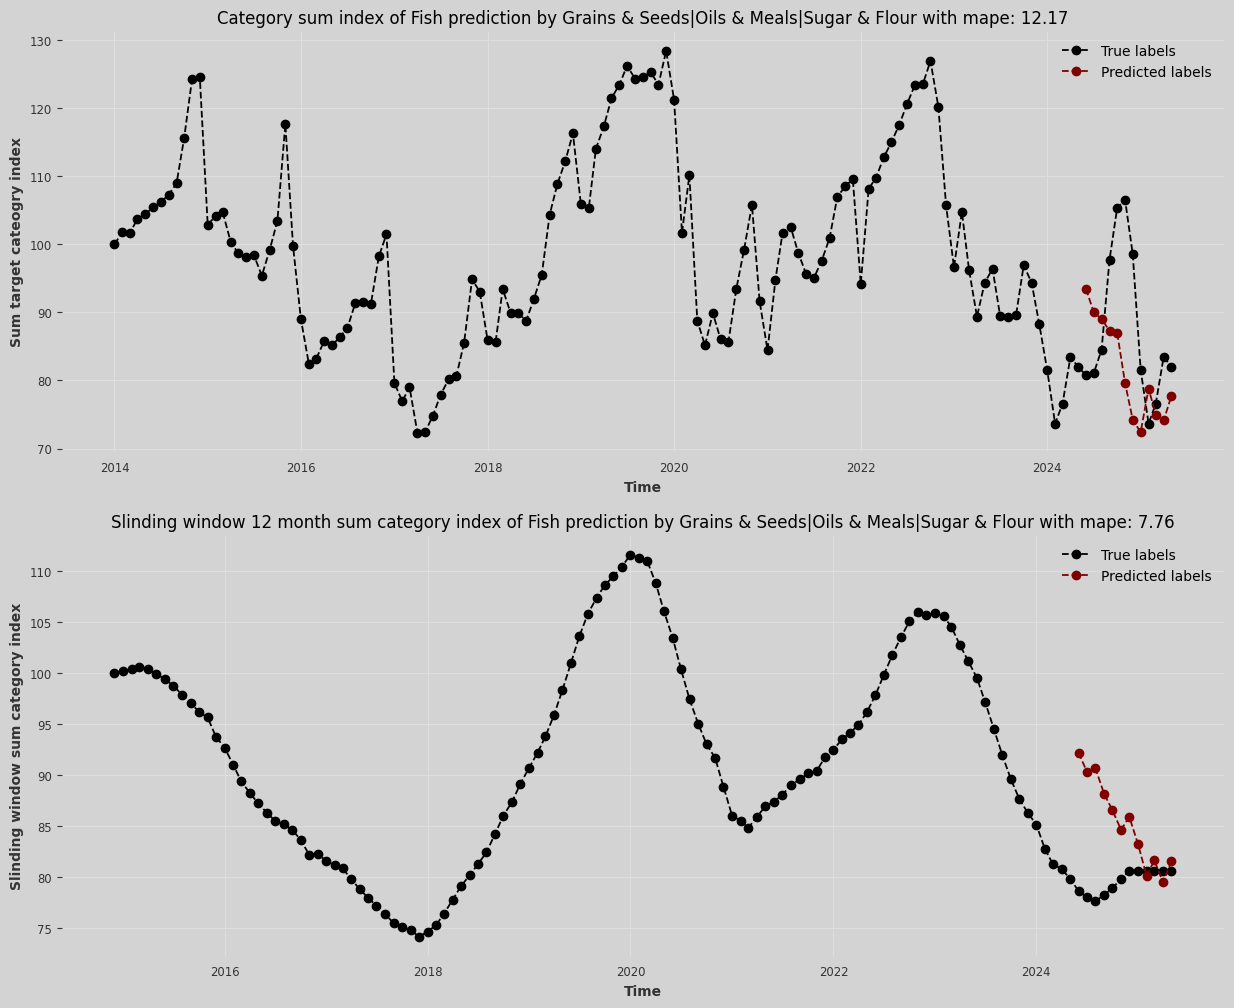

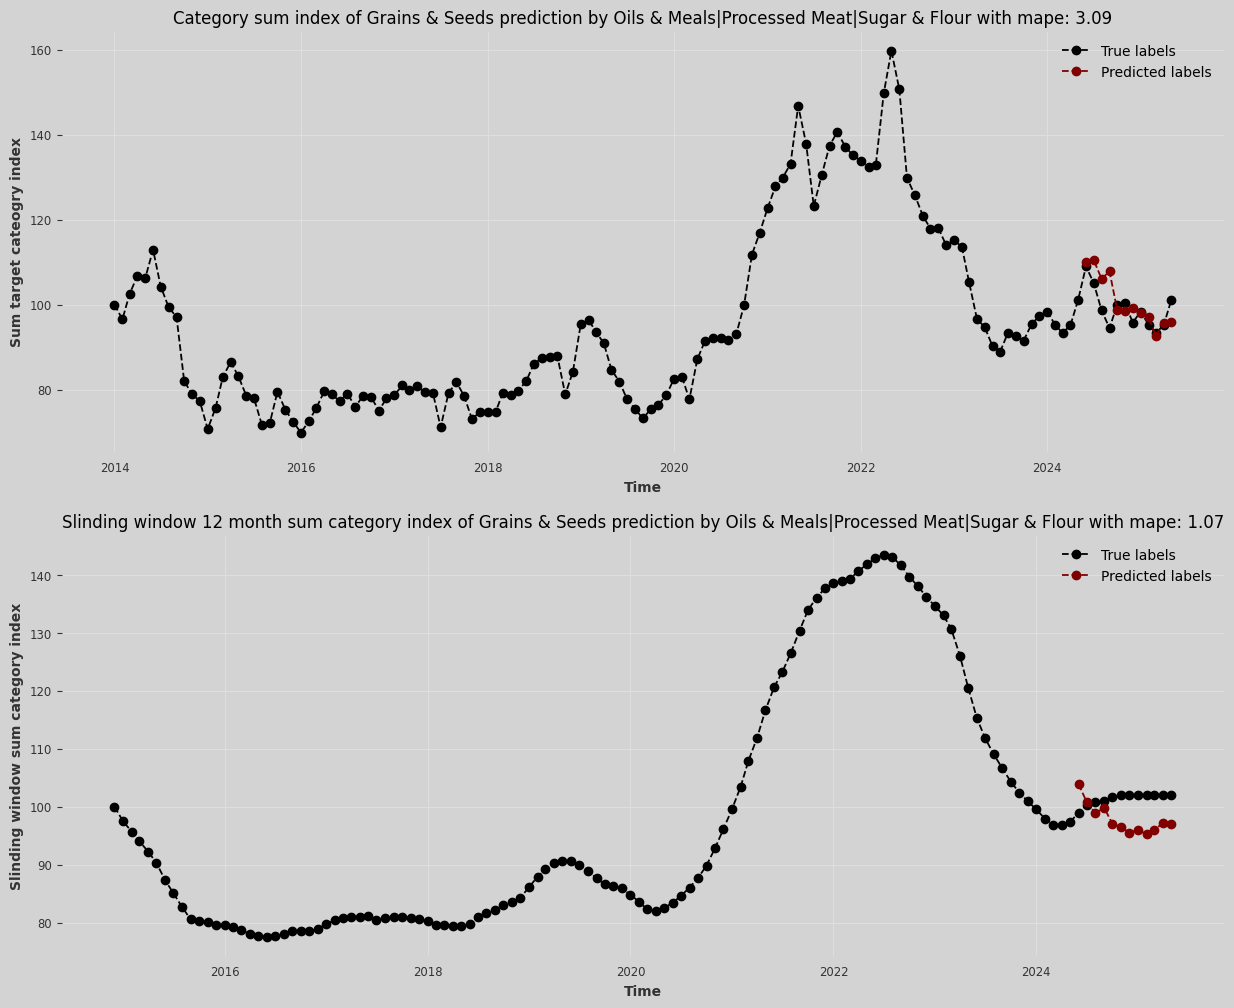

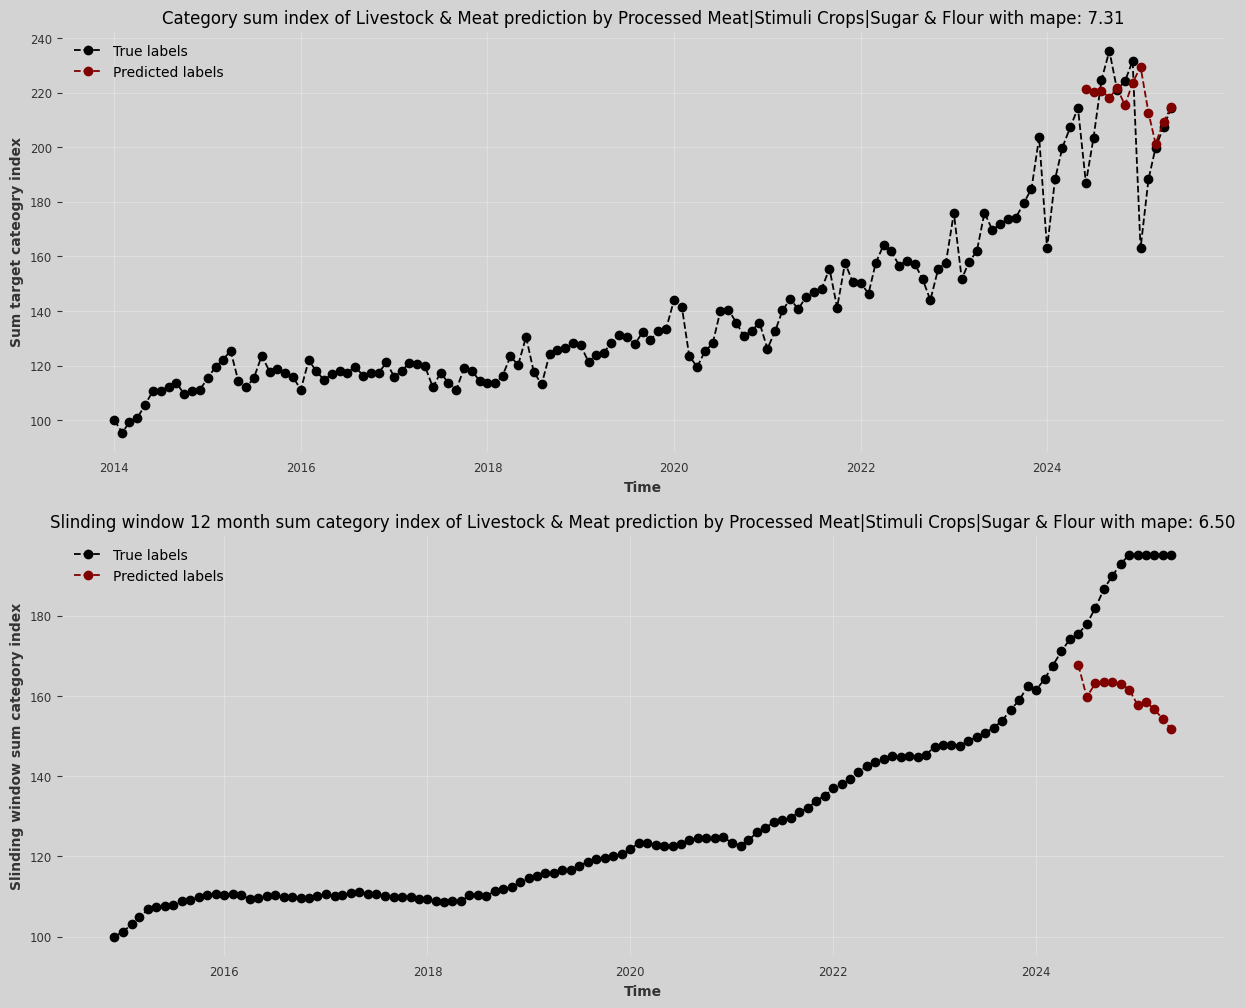

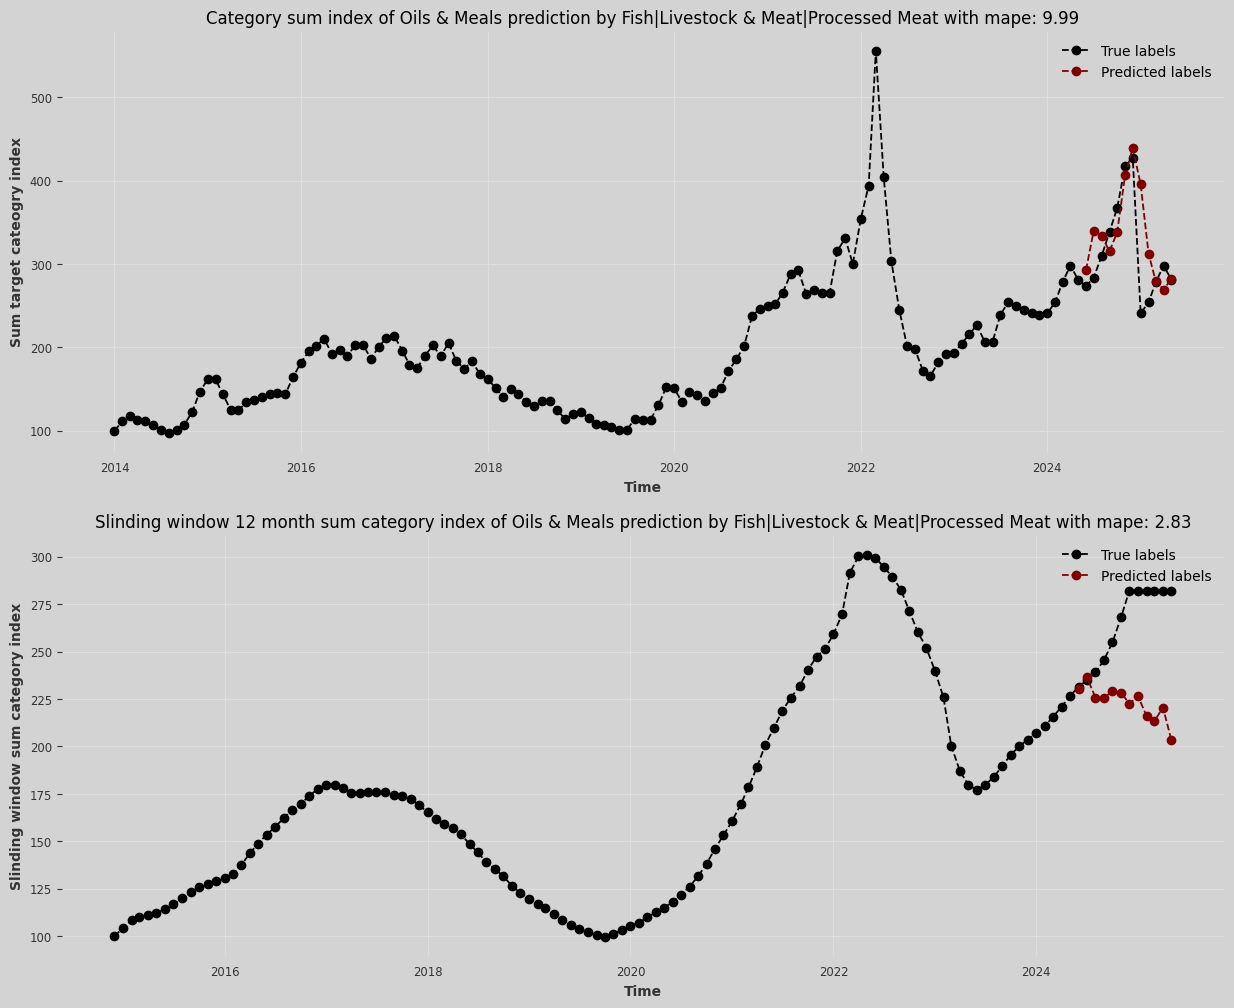

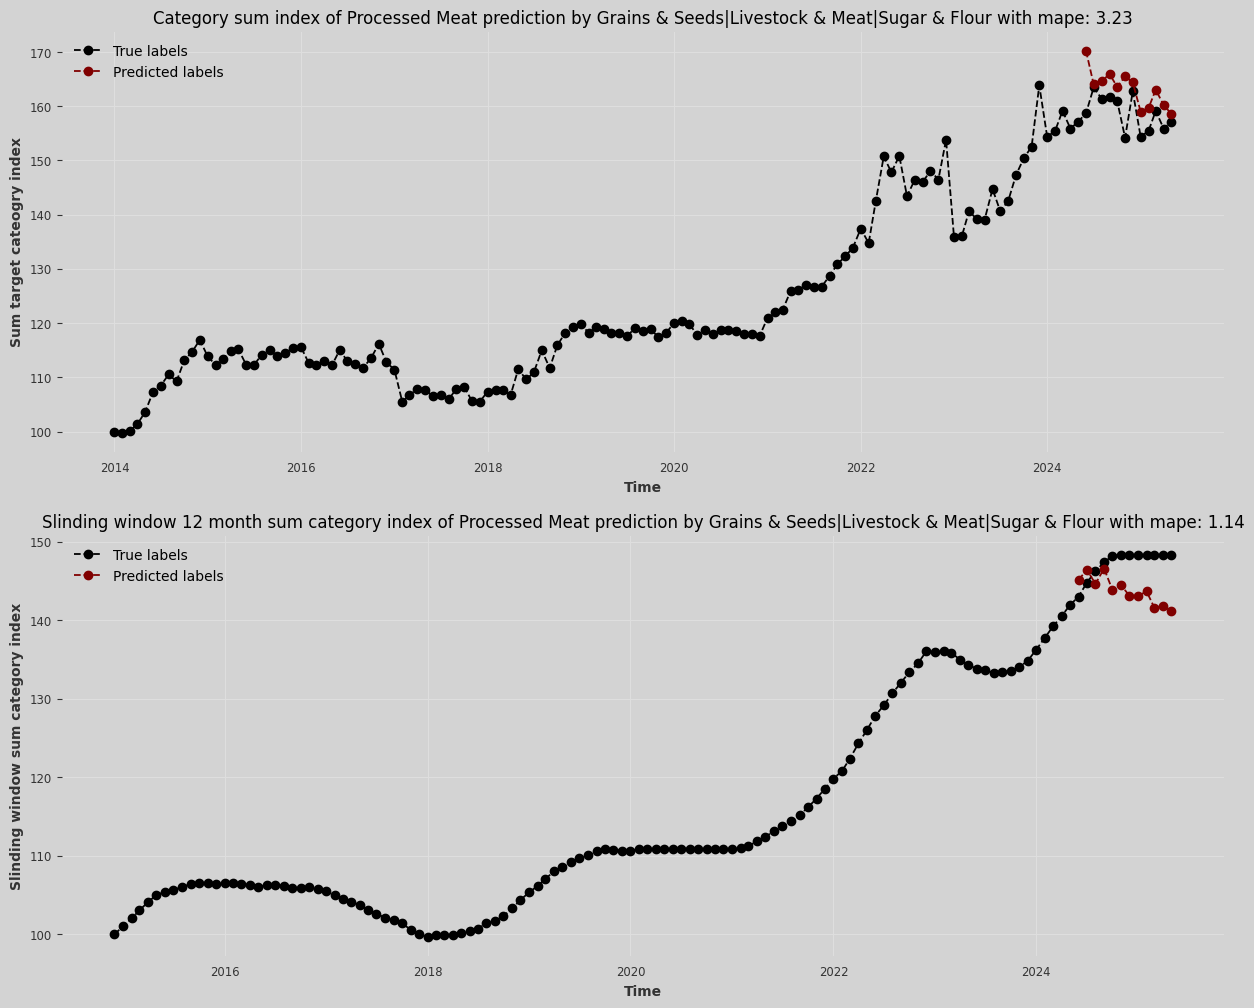

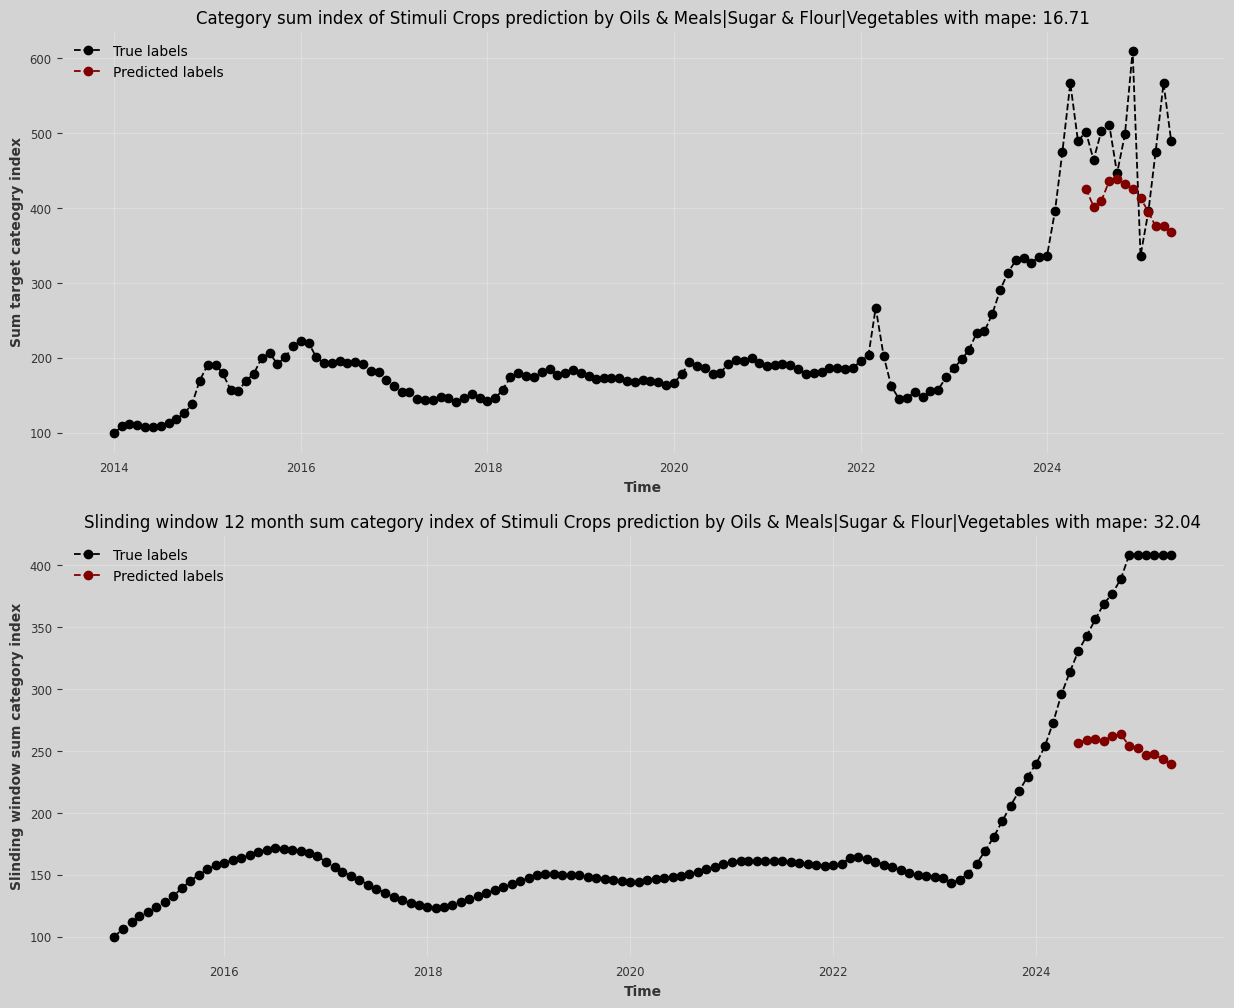

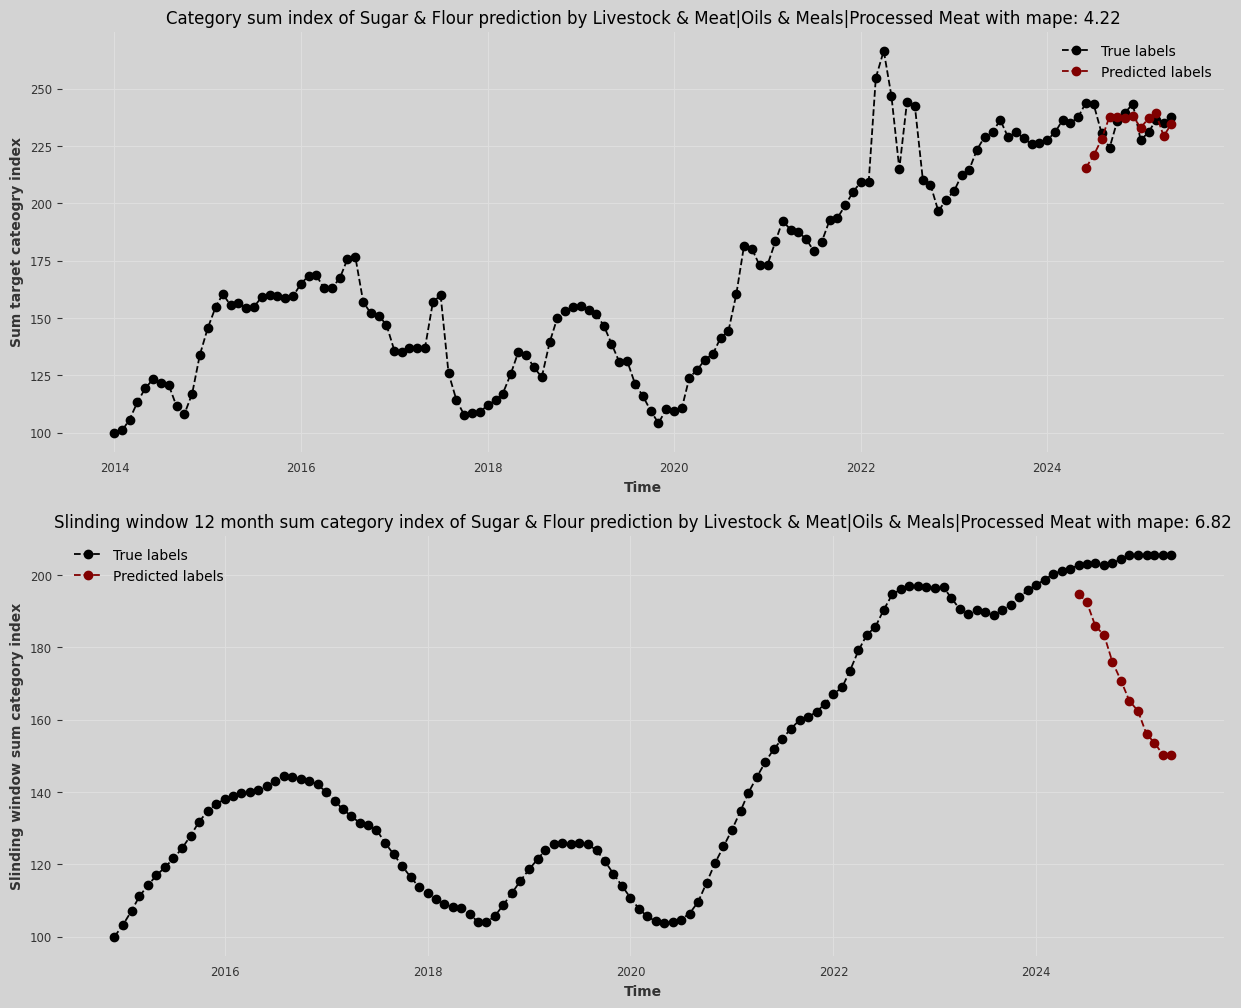

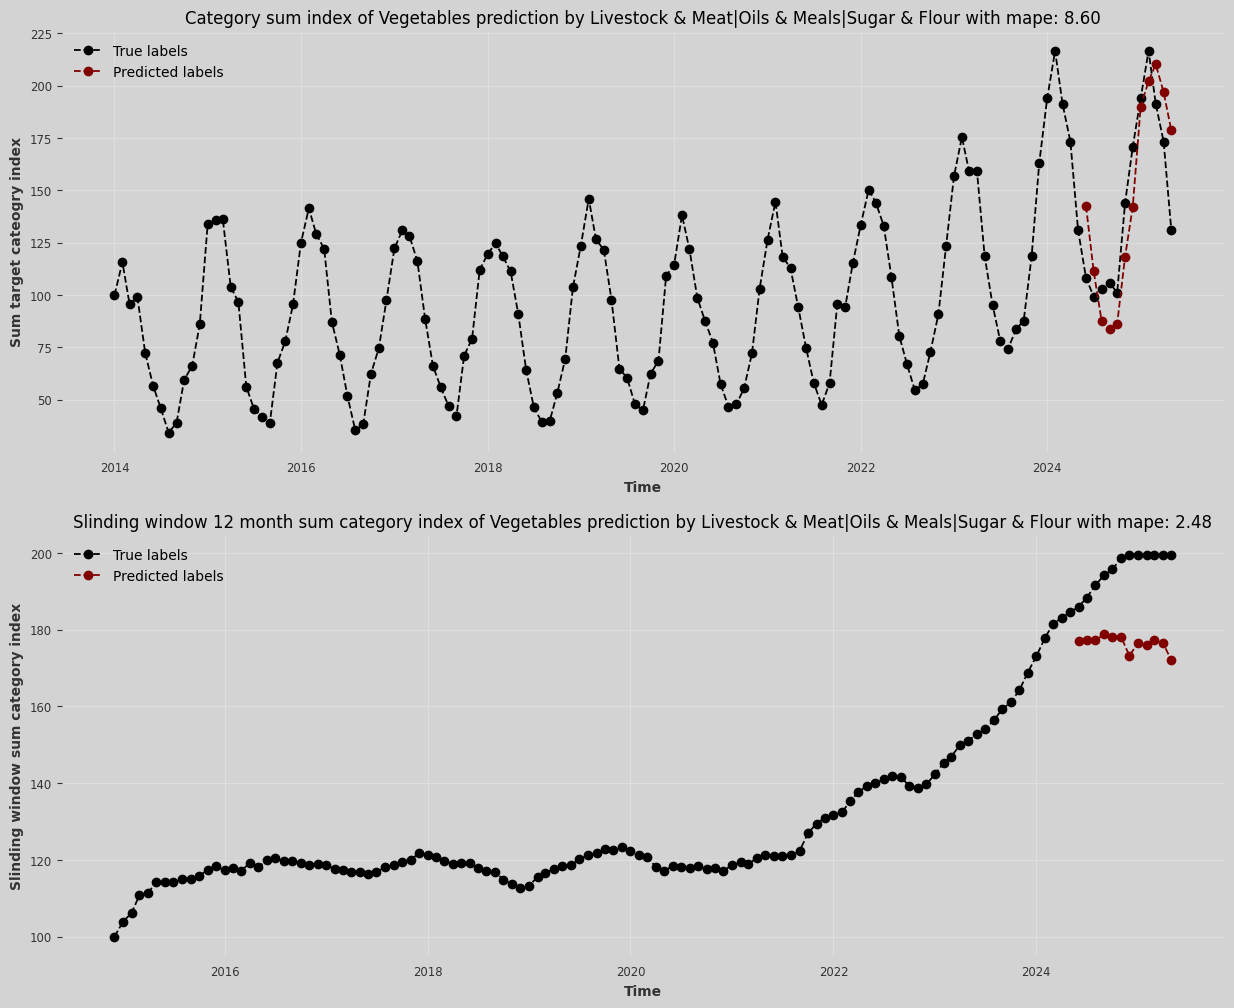

In [221]:
darts_preds_sum = "darts_result_tables_triplets"
darts_preds_12m_sum = "darts_result_tables_12_m_triplets"
plot_best_mape_predictors(apk_nona_en_rol, darts_preds_sum, darts_preds_12m_sum, best_mape_results_sum_triplets, best_mape_results_12m_sum_triplets)

In [30]:
forecast_1

<TimeSeries (Date: 12, component: 1, sample: 1)>
array([[[837.03909705]],

       [[895.97985745]],

       [[915.30758222]],

       [[911.35706736]],

       [[946.64349051]],

       [[933.68179963]],

       [[883.46559073]],

       [[896.26634713]],

       [[866.890408  ]],

       [[862.14383317]],

       [[876.13118552]],

       [[874.40547351]]])
Coordinates:
  * Date       (Date) datetime64[ns] 2025-06-01 2025-07-01 ... 2026-05-01
  * component  (component) object 'Grains & Seeds'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [26]:
apk_nona_en

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,"Мука пшеничная, руб. т","Пшеница 12,5% FOB Ново, $ т",Livestock & Meat_sum,Processed Meat_sum,Stimuli Crops_sum,Fish_sum,Vegetables_sum,Oils & Meals_sum,Grains & Seeds_sum,Sugar & Flour_sum
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,11.66556,281.67,484.852870,571.596360,2.672163e+05,1447.878788,198.08475,74027.447654,817.413751,32.293380
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,11.59769,278.50,463.050970,570.527210,2.894242e+05,1473.560606,229.16299,82295.780217,788.882961,32.644840
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,11.78734,290.75,481.669150,572.090620,2.989678e+05,1471.212121,189.43926,86906.511156,837.588143,34.142270
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,12.26536,291.00,488.960860,579.627080,2.953990e+05,1501.181818,195.83359,83399.250515,873.080043,36.598520
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,12.84780,269.75,512.556390,592.300650,2.889496e+05,1511.590909,143.69519,82598.509165,867.529817,38.517050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,21.35402,240.00,790.013237,882.217153,8.989631e+05,1180.454545,384.05946,178183.579059,803.923643,73.516214
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,21.57677,222.25,912.430985,888.523148,1.058022e+06,1066.363636,428.96817,187975.986635,778.479784,74.599497
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,21.60039,204.00,969.207520,909.539989,1.269732e+06,1108.409091,378.94313,205774.443521,762.691952,76.309481


In [20]:
apk_nona_en.columns

Index(['Unnamed: 0', 'USDRUB', 'Кукуруза', 'Молоко сырое',
       'Мясо птицы бройлеров в живом весе ',
       'Мясо крупного рогатого скота в живом весе ', 'Подсолнечник',
       'Пшеница 1-го класса', 'Пшеница 3-го класса', 'Пшеница 5-го класса',
       'Сахар (средняя цена по России)', 'Свинина в живом весе',
       'Соевое масло', 'Соевый шрот', 'Соя', 'Яйцо товарное',
       'Подсолнечное масло наливом (мировые цены)',
       'Бутилированное подсолнечное масло (рафинированное)',
       'Подсолнечный шрот ', 'Колбасы сырокопченые', 'Баранина в живом весе',
       'Баранина в убойном весе ', 'Какао-бобы (USD)', 'Какао-бобы',
       'Подсолнечное масло (наливом) не бутилированное, нерафинированное ',
       'Кокосовое масло (USD) ', 'Кокосовое масло ', 'Пальмовое масло (USD)',
       'Пальмовое масло ', 'Табак (USD)', 'Табак', 'Пшеница 4-го класса',
       'Минтай б/г, Владивосток руб./кг', 'Минтай б/г, Китай C&F $/т',
       'Сельдь н/р, Владивосток руб./кг', 'Огурцы тепличные, руб.

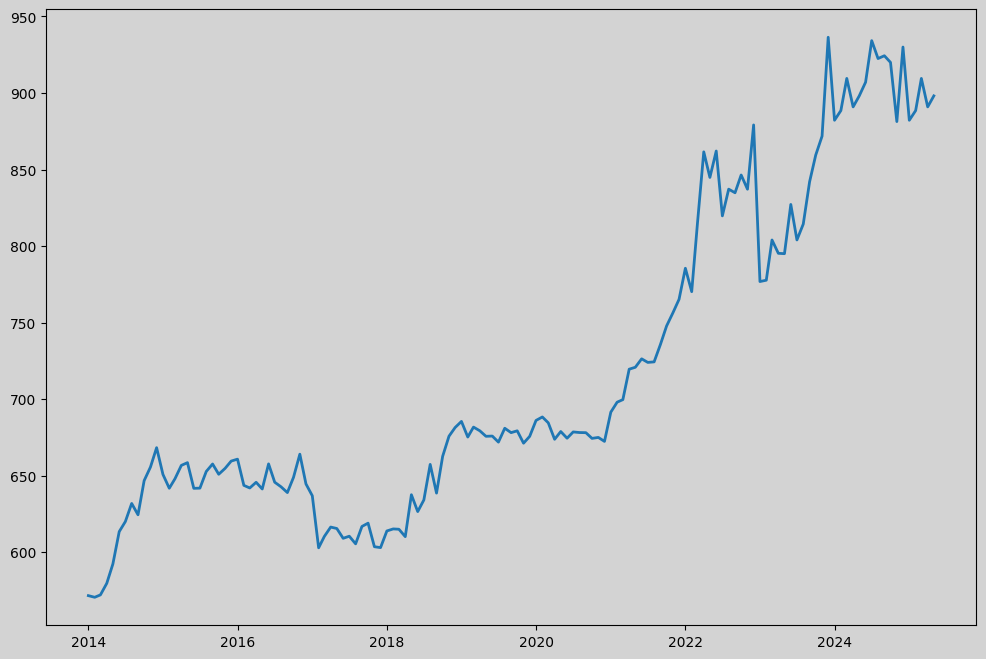

In [19]:
plot_trend_for_cat(apk_nona_en, "Processed Meat")

In [13]:
apk_nona_en

,Unnamed: 0,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,...,"Минтай б/г, Владивосток руб./кг","Минтай б/г, Китай C&F $/т","Сельдь н/р, Владивосток руб./кг","Огурцы тепличные, руб./кг","Томаты тепличные, руб./кг",Колбасы вареные,"Рапс, руб./т","Рапсовое масло EU, $/т","Мука пшеничная, руб./т","Пшеница 12,5% FOB Ново, $/т"
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.354690,6.280540,6.643890,6.301820,...,50.606061,1370.0,27.272727,109.69276,88.39199,180.118840,10.921240,959.902109,11.66556,281.67
2014-02-01,2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.948730,6.703800,6.835350,6.172930,...,46.969697,1400.0,26.590909,133.35480,95.80819,185.952260,11.777070,1025.767008,11.59769,278.50
2014-03-01,2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.374500,7.572830,7.188960,6.005710,...,53.939394,1390.0,27.272727,103.82040,85.61886,189.096880,13.147950,1008.712498,11.78734,290.75
2014-04-01,2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.977020,8.143270,7.549900,6.583600,...,48.000000,1425.0,28.181818,86.43050,109.40309,191.130370,12.713990,1016.669062,12.26536,291.00
2014-05-01,2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.599550,10.168250,8.128110,7.100440,...,47.727273,1440.0,23.863636,61.65754,82.03765,196.688230,11.035150,957.679643,12.84780,269.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,2025-01-01,100.8700,9.88611,33.78862,122.24555,151.65117,26.193182,10.036364,13.019091,9.183409,...,97.045455,1000.0,83.409091,189.07463,194.98483,299.987126,31.943182,940.000000,21.35402,240.00
2025-02-01,2025-02-01,92.8200,10.02863,34.29801,117.15675,148.81030,26.215909,9.886591,12.859091,9.172727,...,83.181818,900.0,83.181818,199.51996,229.44821,301.577058,32.863636,930.000000,21.57677,222.25
2025-03-01,2025-03-01,86.0700,10.22543,34.50990,113.32584,160.52646,26.125000,9.813273,12.474000,9.199273,...,80.454545,950.0,77.954545,133.83385,245.10928,306.100714,36.113636,992.000000,21.60039,204.00
